In [30]:
print("hello")

hello


In [11]:
# ============================================================
# 1️⃣ Setup — imports and configuration
# ============================================================
import os
import pandas as pd
import subprocess
from tqdm import tqdm

INPUT_DIR = "/workspace/content/pcaps"      # 🔹 change this
OUTPUT_CSV = "/workspace/content/final_labelled_dataset.csv"

# Columns you want from tshark (must ensure consistency)
TSHARK_FIELDS = [
    "frame.number",
    "frame.len",
    "frame.time_epoch",
    "ip.src",
    "ip.dst",
    "ip.proto",
    "tcp.srcport",
    "tcp.dstport",
    "udp.srcport",
    "udp.dstport",
    "icmp.type",
    "icmp.code"
]

TSHARK_FIELD_ARGS = []
for f in TSHARK_FIELDS:
    TSHARK_FIELD_ARGS += ["-e", f]




In [7]:
# ============================================================
# Detect the correct label based on filename
# ============================================================
def detect_label(filename):

    fname = filename.lower()

    # Attack keyword detection (priority)
    attack_keywords = {
        "tcp": "tcp_synflood",
        "udp": "udpflood",
        "portscan": "portscan",
        "brute": "bruteforce",
        "icmp": "icmpflood",
        "mitm": "mitm"
    }
    for key, label in attack_keywords.items():
        if key in fname:
            return label

    # VPN vs Non-VPN classification
    if fname.startswith("vpn"):
        return "vpn"
    
    non_vpn_prefixes = ("email", "facebook", "aim_chat")
    if any(fname.startswith(p) for p in non_vpn_prefixes):
        return "non_vpn"

    return "unknown"


In [12]:
# ============================================================
# Convert a single pcap/pcapng file to a dataframe
# ============================================================
def pcap_to_df(pcap_path):
    cmd = [
        "tshark",
        "-r", pcap_path,
        "-T", "fields",
    ] + TSHARK_FIELD_ARGS

    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

    if result.returncode != 0:
        print(f"Error converting {pcap_path}:")
        print(result.stderr)
        return None

    # Convert output into dataframe
    data = [line.split("\t") for line in result.stdout.splitlines()]
    df = pd.DataFrame(data, columns=TSHARK_FIELDS)

    # Handle missing columns
    for col in TSHARK_FIELDS:
        if col not in df:
            df[col] = None

    return df


In [13]:
# ============================================================
# Process all pcap files and create merged labelled dataset
# ============================================================
all_dfs = []

for file in tqdm(os.listdir(INPUT_DIR)):
    if not (file.endswith(".pcap") or file.endswith(".pcapng")):
        continue

    full_path = os.path.join(INPUT_DIR, file)
    label = detect_label(file)

    print(f"\nProcessing: {file} → Label = {label}")

    df = pcap_to_df(full_path)
    if df is None:
        continue

    df["label"] = label
    df["source_file"] = file

    all_dfs.append(df)

# Merge all into one dataset
if all_dfs:
    final_df = pd.concat(all_dfs, ignore_index=True)

    # Fill missing columns (normalization)
    for col in TSHARK_FIELDS:
        if col not in final_df:
            final_df[col] = None

    # Save final CSV
    final_df.to_csv(OUTPUT_CSV, index=False)
    print(f"\n✅ DONE! Final CSV saved at: {OUTPUT_CSV}")
else:
    print("❌ No pcap files processed!")


  0%|          | 0/72 [00:00<?, ?it/s]


Processing: aim_chat_3a.pcap → Label = non_vpn


  3%|▎         | 2/72 [00:00<00:13,  5.36it/s]


Processing: AIMchat1.pcapng → Label = unknown

Processing: aim_chat_3b.pcap → Label = non_vpn


  6%|▌         | 4/72 [00:00<00:12,  5.50it/s]

...


Processing: icmpflood2.pcap → Label = icmpflood


 96%|█████████▌| 69/72 [07:35<01:08, 22.77s/it]


Processing: icmpflood4.pcap → Label = icmpflood



00%|██████████| 72/72 [07:57<00:00,  6.64s/it]


✅ DONE! Final CSV saved at: /workspace/content/final_labelled_dataset.csv


In [14]:
final_df.head()


,frame.number,frame.len,frame.time_epoch,ip.src,ip.dst,ip.proto,tcp.srcport,tcp.dstport,udp.srcport,udp.dstport,icmp.type,icmp.code,label,source_file
0,1,60,1430325788.001040000,131.202.240.87,178.237.19.228,6,42534,443,,,,,non_vpn,aim_chat_3a.pcap
1,2,60,1430325788.001690000,131.202.240.87,178.237.17.103,6,42530,443,,,,,non_vpn,aim_chat_3a.pcap
2,3,60,1430325788.172106000,178.237.17.103,131.202.240.87,6,443,42530,,,,,non_vpn,aim_chat_3a.pcap
3,4,60,1430325788.173710000,178.237.19.228,131.202.240.87,6,443,42534,,,,,non_vpn,aim_chat_3a.pcap
4,5,331,1430325803.394782000,205.188.12.91,131.202.240.87,6,443,42522,,,,,non_vpn,aim_chat_3a.pcap


In [22]:
# ==============================================================
# UNIVERSAL PREPROCESSING PIPELINE FOR NETWORK DATA (ONE CELL)
# ==============================================================

import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# --------------------------------------------------------------
# 1. Load Dataset
# --------------------------------------------------------------
df = pd.read_csv("/workspace/content/final_labelled_dataset.csv", low_memory=False)

print("Dataset Shape:", df.shape)

# --------------------------------------------------------------
# 2. Drop columns that should NOT be one-hot encoded
#    (IP addresses cause memory explosion; categorical too large)
# --------------------------------------------------------------
cols_to_drop = ["ip.src", "ip.dst", "source_file"]
df = df.drop(columns=cols_to_drop, errors="ignore")

# --------------------------------------------------------------
# 3. Extract labels
# --------------------------------------------------------------
y = df["label"]
X = df.drop("label", axis=1)

# --------------------------------------------------------------
# 4. Encode labels (attacks)
# --------------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(y)

print("\nLabel Mapping:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"{cls} → {enc}")

# --------------------------------------------------------------
# 5. Auto-detect feature types
# --------------------------------------------------------------
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("\nNumeric Features:", list(numeric_features))
print("Categorical Features:", list(categorical_features))

# --------------------------------------------------------------
# 6. Fix OneHotEncoder error: convert categorical to strings
# --------------------------------------------------------------
X[categorical_features] = X[categorical_features].astype(str)

# --------------------------------------------------------------
# 7. Define Pipelines
# --------------------------------------------------------------

# Numeric Pipeline → impute + minmax scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Categorical Pipeline → impute + onehot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --------------------------------------------------------------
# 8. Combine Pipelines
# --------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)

# --------------------------------------------------------------
# 9. Fit + Transform the Dataset
# --------------------------------------------------------------
print("\nPreprocessing... (this may take a while)")
X_processed = preprocessor.fit_transform(X)

print("\nFinal preprocessed shape:", X_processed.shape)


Dataset Shape: (20715742, 14)

Label Mapping:
bruteforce → 0
icmpflood → 1
mitm → 2
non_vpn → 3
portscan → 4
tcp_synflood → 5
udpflood → 6
unknown → 7
vpn → 8

Numeric Features: ['frame.number', 'frame.len', 'frame.time_epoch', 'tcp.srcport', 'tcp.dstport', 'udp.srcport', 'udp.dstport', 'icmp.type', 'icmp.code']
Categorical Features: ['ip.proto']

Preprocessing... (this may take a while)

Final preprocessed shape: (20715742, 17)


In [28]:
# ==============================================================
# RANDOM FOREST TRAINING PIPELINE (ONE CELL)
# ==============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

# --------------------------------------------------------------
# 1. Train-Test Split (Stratified)
# --------------------------------------------------------------
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

# --------------------------------------------------------------
# 2. Random Forest Classifier
#    Optimized for large datasets (20M+ rows)
# --------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=200,          # number of trees
    max_depth=None,           # allow deep trees
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    n_jobs=-1,                # use all CPU cores
    random_state=42
)

# --------------------------------------------------------------
# 3. Train the model
# --------------------------------------------------------------
print("\nTraining Random Forest...")
start = time.time()
rf.fit(X_train, y_train)
end = time.time()

print(f"Training completed in {(end - start):.2f} seconds")

# --------------------------------------------------------------
# 4. Predictions
# --------------------------------------------------------------
print("\nPredicting...")
y_pred = rf.predict(X_test)

# --------------------------------------------------------------
# 5. Evaluation
# --------------------------------------------------------------
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Splitting data...
Training samples: (16572593, 17)
Testing samples: (4143149, 17)

Training Random Forest...
Training completed in 281.58 seconds

Predicting...

Model Accuracy: 0.9999975863769321

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386383
           1       1.00      1.00      1.00    858227
           2       1.00      1.00      1.00        85
           3       1.00      1.00      1.00    558585
           4       1.00      1.00      1.00     33739
           5       1.00      1.00      1.00    773181
           6       1.00      1.00      1.00    565599
           7       1.00      0.99      1.00       154
           8       1.00      1.00      1.00    967196

    accuracy                           1.00   4143149
   macro avg       1.00      1.00      1.00   4143149
weighted avg       1.00      1.00      1.00   4143149



Running 3-fold cross-validation on 500,000 samples...

Cross-Validation Scores: [0.999928 0.999904 0.999928]
Mean CV Score: 0.9999200000159995
Std. Dev: 1.1313584049399448e-05

Top 17 Most Important Features:

1. num__frame.time_epoch: 0.3356
2. cat__ip.proto_1: 0.1501
3. num__frame.len: 0.1080
4. num__udp.dstport: 0.0951
5. cat__ip.proto_6: 0.0747
6. num__frame.number: 0.0586
7. cat__ip.proto_17: 0.0504
8. num__tcp.dstport: 0.0422
9. num__udp.srcport: 0.0403
10. num__tcp.srcport: 0.0327
11. num__icmp.type: 0.0075
12. cat__ip.proto_nan: 0.0046
13. cat__ip.proto_2: 0.0000
14. cat__ip.proto_1,17: 0.0000
15. num__icmp.code: 0.0000
16. cat__ip.proto_1,6: 0.0000
17. cat__ip.proto_1,2: 0.0000


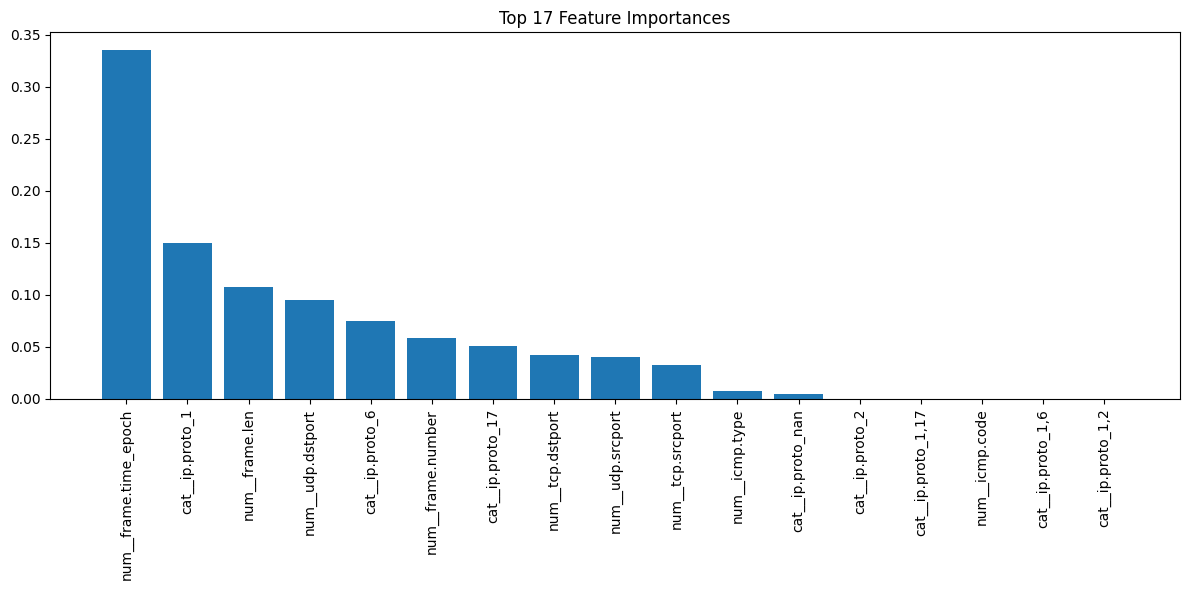

In [33]:
# ===============================================================
# FULL CROSS-VALIDATION + FEATURE IMPORTANCE (ONE CELL)
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# ===============================================================
# 1. CROSS-VALIDATION (SAFE FOR 20M+ ROW DATASETS)
# ===============================================================

# Large datasets cannot run CV on full data → sample instead
SAMPLE_SIZE = 500_000  # adjust to 1,000,000 if RAM allows

# Random sample indices
sample_idx = np.random.choice(len(y), size=SAMPLE_SIZE, replace=False)

X_sample = X_processed[sample_idx]
y_sample = y[sample_idx]

print(f"Running 3-fold cross-validation on {SAMPLE_SIZE:,} samples...\n")

cv_scores = cross_val_score(
    rf,
    X_sample,
    y_sample,
    cv=3,
    n_jobs=-1
)

print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))
print("Std. Dev:", np.std(cv_scores))


# ===============================================================
# 2. FEATURE IMPORTANCE EXTRACTION (SAFE FOR ANY FEATURE COUNT)
# ===============================================================

# Extract transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Importance values from Random Forest
importances = rf.feature_importances_

# Sort in descending order
indices = np.argsort(importances)[::-1]

# Safely determine how many features exist
num_features = len(importances)
top_k = min(20, num_features)

print(f"\nTop {top_k} Most Important Features:\n")

for i in range(top_k):
    idx = indices[i]
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")


# ===============================================================
# 3. PLOT TOP FEATURE IMPORTANCES
# ===============================================================

plt.figure(figsize=(12, 6))
plt.title(f"Top {top_k} Feature Importances")
plt.bar(range(top_k), importances[indices][:top_k])
plt.xticks(range(top_k), feature_names[indices][:top_k], rotation=90)
plt.tight_layout()
plt.show()


In [34]:
# ===============================================================
# XGBOOST ENSEMBLE MODEL FOR ATTACK PREDICTION (ONE CELL)
# ==============================================================

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import time

# ---------------------------------------------------------------
# 1. 70/30 Train-Test Split
# ---------------------------------------------------------------
print("Splitting dataset (70% train / 30% test)...")

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, 
    y, 
    test_size=0.30, 
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

# ---------------------------------------------------------------
# 2. XGBoost Model for Multiclass Attack Detection
# ---------------------------------------------------------------
xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    tree_method="gpu_hist",     # efficient for large datasets
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=500,
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)

# ---------------------------------------------------------------
# 3. Train the Model
# ---------------------------------------------------------------
print("\nTraining XGBoost (this may take a few minutes)...")
start = time.time()
xgb_model.fit(X_train, y_train)
end = time.time()

print(f"Training completed in {end - start:.2f} seconds")

# ---------------------------------------------------------------
# 4. Predictions
# ---------------------------------------------------------------
print("\nPredicting on test data...")
y_pred = xgb_model.predict(X_test)

# ---------------------------------------------------------------
# 5. Evaluation Metrics
# ---------------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\n==========================")
print("XGBoost Model Performance")
print("==========================")
print(f"Accuracy: {accuracy:.6f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))


Splitting dataset (70% train / 30% test)...
Training samples: (14501019, 17)
Testing samples: (6214723, 17)

Training XGBoost (this may take a few minutes)...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:158: UserWarning: [16:38:30] WARNING: /home/coder/xgboost/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


Training completed in 88.60 seconds

Predicting on test data...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:158: UserWarning: [16:39:53] WARNING: /home/coder/xgboost/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:158: UserWarning: [16:39:53] WARNING: /home/coder/xgboost/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



XGBoost Model Performance
Accuracy: 0.999977

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    579575
           1     1.0000    1.0000    1.0000   1287340
           2     0.8750    0.9844    0.9265       128
           3     0.9999    1.0000    0.9999    837878
           4     1.0000    0.9999    0.9999     50608
           5     1.0000    1.0000    1.0000   1159771
           6     1.0000    1.0000    1.0000    848398
           7     0.9286    0.8442    0.8844       231
           8     1.0000    1.0000    1.0000   1450794

    accuracy                         1.0000   6214723
   macro avg     0.9782    0.9809    0.9790   6214723
weighted avg     1.0000    1.0000    1.0000   6214723



In [35]:
import numpy as np
import pandas as pd

# =============================================================
# 1. Extract the feature names after preprocessing
# =============================================================
feature_names = preprocessor.get_feature_names_out()

num_features = len(feature_names)
print("Model feature count:", num_features)

# =============================================================
# 2. Generate Fake Random Packets
# =============================================================
N_FAKE = 5000  # number of synthetic packets to generate

fake_samples = {}

rng = np.random.default_rng()

for name in feature_names:
    if "frame.len" in name:
        fake_samples[name] = rng.integers(40, 1500, size=N_FAKE)

    elif "frame.time_epoch" in name:
        fake_samples[name] = rng.uniform(1.7e9, 1.71e9, size=N_FAKE)

    elif "tcp.srcport" in name or "tcp.dstport" in name:
        fake_samples[name] = rng.integers(0, 65535, size=N_FAKE)

    elif "udp.srcport" in name or "udp.dstport" in name:
        fake_samples[name] = rng.integers(0, 65535, size=N_FAKE)

    elif "icmp.type" in name:
        fake_samples[name] = rng.integers(0, 18, size=N_FAKE)

    elif "icmp.code" in name:
        fake_samples[name] = rng.integers(0, 15, size=N_FAKE)

    elif "frame.number" in name:
        fake_samples[name] = rng.integers(1, 10_000_000, size=N_FAKE)

    # One-Hot categorical features (ip.proto_*):
    elif "cat__ip.proto" in name:
        fake_samples[name] = rng.integers(0, 2, size=N_FAKE)

    else:
        fake_samples[name] = rng.uniform(0, 1, size=N_FAKE)

# Convert to DataFrame
fake_df = pd.DataFrame(fake_samples)
print("Generated fake packet dataframe:", fake_df.shape)

# =============================================================
# 3. Predict Malicious / Normal on Fake Packets
# =============================================================
# Choose your model:
# preds = rf.predict(fake_df)
preds = xgb_model.predict(fake_df)

# Decode predicted labels back to names
decoded_preds = le.inverse_transform(preds)

# Calculate distribution
unique, counts = np.unique(decoded_preds, return_counts=True)
results = dict(zip(unique, counts))

print("\nPrediction distribution on FAKE synthetic traffic:")
for k, v in results.items():
    print(f"{k}: {v}")



Model feature count: 17
Generated fake packet dataframe: (5000, 17)

Prediction distribution on FAKE synthetic traffic:
portscan: 5000


In [37]:
# -------------------------
# Synthetic + Hybrid Traffic Generator (safe & realistic)
# -------------------------
import numpy as np
import pandas as pd
from collections import Counter

# CONFIG
N_SYNTH = 5000        # number of sampled realistic synthetic rows
N_HYBRID = 2000       # number of hybrid (mixed) rows
PROB_THRESHOLD = 0.6  # probability threshold: below -> label "low_confidence"

# You should have:
# - df : original raw DataFrame with raw features (before preprocessor), including columns like:
#       ['frame.number','frame.len','frame.time_epoch','ip.src','ip.dst','ip.proto',
#        'tcp.srcport','tcp.dstport','udp.srcport','udp.dstport','icmp.type','icmp.code','label', ...]
# - preprocessor : your fitted ColumnTransformer
# - le : fitted LabelEncoder
# - rf or xgb_model : trained classifier (choose model variable name accordingly)

# SAFE CHECKS
raw_df = df.copy()  # use the original DataFrame you created earlier
required_cols = list(raw_df.columns)
print("Raw DF columns:", required_cols)
# -------------------------------------------------------
# 1) Sampling-based synthetic generation: sample each raw column from empirical distribution
# -------------------------------------------------------
rng = np.random.default_rng()

def sample_column_empirical(col, n):
    """Sample n values from empirical distribution of raw_df[col] with replacement."""
    vals = raw_df[col].dropna().values
    if len(vals) == 0:
        # fallback: numeric 0s
        return np.full(n, np.nan)
    return rng.choice(vals, size=n, replace=True)

# Build synthetic raw DataFrame
sampled = {}
for col in raw_df.columns:
    if col == "label":
        continue
    sampled[col] = sample_column_empirical(col, N_SYNTH)

synth_raw = pd.DataFrame(sampled)
synth_raw = synth_raw.reset_index(drop=True)
print("Synth raw shape:", synth_raw.shape)

# -------------------------------------------------------
# 2) Hybrid generation: mix columns from random rows to create impossible combos
# -------------------------------------------------------
def make_hybrid_rows(n):
    rows = []
    cols = [c for c in raw_df.columns if c != "label"]
    idxs = rng.integers(0, len(raw_df), size=(n, 3))  # use 3 donor rows for mixing
    for i in range(n):
        donors = raw_df.iloc[idxs[i]]
        # Strategy: take time from donor0, ports from donor1, proto from donor2, lengths random
        row = {}
        row_vals = donors.to_dict(orient='list')
        # simple heuristic mixing:
        for c in cols:
            if "time" in c or "frame.number" in c:
                row[c] = donors.iloc[0][c]
            elif ("srcport" in c) or ("dstport" in c) or ("port" in c):
                row[c] = donors.iloc[1][c]
            elif c == "ip.proto":
                row[c] = donors.iloc[2][c]
            elif "ip.src" in c or "ip.dst" in c:
                # randomize IPs among donors
                row[c] = donors.sample(1, random_state=rng.integers(0,1e9))[c].values[0]
            elif "len" in c:
                # slightly perturb length
                base = donors.iloc[0][c]
                try:
                    row[c] = max(1, int(base) + rng.integers(-50,50))
                except:
                    row[c] = base
            else:
                row[c] = donors.iloc[0][c]
        rows.append(row)
    return pd.DataFrame(rows)

hybrid_raw = make_hybrid_rows(N_HYBRID)
print("Hybrid raw shape:", hybrid_raw.shape)

# -------------------------------------------------------
# 3) Combine and transform using your preprocessor
# -------------------------------------------------------
combined_raw = pd.concat([synth_raw, hybrid_raw], ignore_index=True)
print("Combined raw shape:", combined_raw.shape)

# Fill or coerce types if preprocessor expects numeric types
# (e.g. ports should be numeric; if strings like 'nan' exist, coerce)
for col in combined_raw.columns:
    # try convert numeric columns using existing numeric columns heuristics
    if combined_raw[col].dropna().shape[0] == 0:
        continue
    # If column in original numeric features, coerce to numeric where possible
    if col in ['frame.number','frame.len','frame.time_epoch','tcp.srcport','tcp.dstport','udp.srcport','udp.dstport','icmp.type','icmp.code']:
        combined_raw[col] = pd.to_numeric(combined_raw[col], errors='coerce')

# Now transform with preprocessor (which handles imputing and OHE properly)
X_synth = preprocessor.transform(combined_raw)

print("Transformed synthetic shape:", X_synth.shape)

# -------------------------------------------------------
# 4) Predict with model and examine probabilities
# -------------------------------------------------------
# choose your model (rf or xgb_model). If you trained both, pick one variable:
model = None
if 'xgb_model' in globals():
    model = xgb_model
elif 'rf' in globals():
    model = rf
else:
    raise RuntimeError("No trained model found in variables 'xgb_model' or 'rf'.")

probs = model.predict_proba(X_synth)
preds = model.predict(X_synth)
pred_labels = le.inverse_transform(preds)

# Low-confidence detection
max_probs = probs.max(axis=1)
low_confidence_mask = max_probs < PROB_THRESHOLD
low_conf_count = int(low_confidence_mask.sum())

# Counts
dist = Counter(pred_labels)
print("\nPrediction distribution on combined synthetic + hybrid (total={}):".format(len(pred_labels)))
for k,v in dist.items():
    print(f"{k}: {v}")
print(f"\nLow-confidence (<{PROB_THRESHOLD}) samples: {low_conf_count} ({low_conf_count/len(pred_labels):.2%})")

# -------------------------------------------------------
# 5) Show top-5 examples mis-classified as portscan (or whichever) for inspection
# -------------------------------------------------------
# pick indices where predicted class is 'portscan' (if exists)
target = "portscan"
if target in dist:
    idxs = [i for i,p in enumerate(pred_labels) if p==target]
    print(f"\nShowing 5 synthetic rows predicted as {target} (raw features):")
    display(combined_raw.iloc[idxs[:5]])
else:
    print(f"\nNo predictions as {target} found.")

# Optionally, save synthetic dataset + preds for offline analysis
combined_raw['pred_label'] = pred_labels
combined_raw['pred_prob'] = max_probs
combined_raw.to_csv("synthetic_predictions.csv", index=False)
print("\nSaved synthetic predictions to synthetic_predictions.csv")


Raw DF columns: ['frame.number', 'frame.len', 'frame.time_epoch', 'ip.proto', 'tcp.srcport', 'tcp.dstport', 'udp.srcport', 'udp.dstport', 'icmp.type', 'icmp.code', 'label']
Synth raw shape: (5000, 10)
Hybrid raw shape: (2000, 10)
Combined raw shape: (7000, 10)
Transformed synthetic shape: (7000, 17)

Prediction distribution on combined synthetic + hybrid (total=7000):
udpflood: 1381
tcp_synflood: 821
non_vpn: 910
vpn: 1337
icmpflood: 1798
bruteforce: 699
portscan: 53
unknown: 1

Low-confidence (<0.6) samples: 308 (4.40%)

Showing 5 synthetic rows predicted as portscan (raw features):


,frame.number,frame.len,frame.time_epoch,ip.proto,tcp.srcport,tcp.dstport,udp.srcport,udp.dstport,icmp.type,icmp.code
100,10338,1360,1.760730e+09,17,19687.0,16372.0,38633.0,80.0,0.0,0.0
242,42770,1360,1.760731e+09,17,22.0,80.0,53075.0,80.0,0.0,0.0
249,17299,125,1.760730e+09,6,43533.0,22.0,11666.0,38633.0,8.0,0.0
352,217111,54,1.760730e+09,1,64266.0,80.0,52245.0,38633.0,8.0,0.0
524,451648,60,1.760730e+09,17,43490.0,80.0,40273.0,80.0,8.0,0.0



Saved synthetic predictions to synthetic_predictions.csv


In [39]:
## 1) Add a confidence threshold & label low-confidence samples as “unknown”
## Goal: mark predictions with low predicted probability as unknown so you don’t trust low-confidence model outputs.
## Prereqs: trained model (rf or xgb_model), preprocessor, le, and X_synth or any feature matrix to predict.

from collections import Counter
import numpy as np

# Choose model (RF or XGB)
model = xgb_model if 'xgb_model' in globals() else rf

threshold = 0.6   # tune this based on validation set

# Use X_synth from synthetic generation step
probs = model.predict_proba(X_synth)
max_probs = probs.max(axis=1)

preds = model.predict(X_synth)
pred_labels = le.inverse_transform(preds)

# Apply threshold to convert low-confidence predictions to "unknown"
pred_final = []
for label, prob in zip(pred_labels, max_probs):
    if prob < threshold:
        pred_final.append("unknown")
    else:
        pred_final.append(label)

# Show distribution
print("Prediction distribution (with threshold):")
print(Counter(pred_final))

# Add to combined_raw dataframe for inspection (optional)
combined_raw["pred_with_threshold"] = pred_final
combined_raw["max_prob"] = max_probs

# Show samples that were thresholded out
low_conf_indices = np.where(max_probs < threshold)[0]
print(f"\nLow-confidence samples: {len(low_conf_indices)} ({len(low_conf_indices)/len(pred_final):.2%})")

combined_raw.iloc[low_conf_indices[:5]]



Prediction distribution (with threshold):
Counter({'icmpflood': 1756, 'vpn': 1287, 'udpflood': 1263, 'non_vpn': 888, 'tcp_synflood': 773, 'bruteforce': 678, 'unknown': 309, 'portscan': 46})

Low-confidence samples: 308 (4.40%)


,frame.number,frame.len,frame.time_epoch,ip.proto,tcp.srcport,tcp.dstport,udp.srcport,udp.dstport,icmp.type,icmp.code,pred_label,pred_prob,pred_with_threshold,max_prob
11,404476,1360,1.756319e+09,17,22.0,80.0,1900.0,40273.0,0.0,0.0,udpflood,0.381347,unknown,0.381347
14,52307,60,1.756319e+09,6,55782.0,231.0,38633.0,50768.0,8.0,0.0,udpflood,0.405329,unknown,0.405329
125,751279,1360,1.429035e+09,6,22.0,32826.0,51425.0,80.0,0.0,0.0,vpn,0.557260,unknown,0.557260
146,190351,42,1.756319e+09,17,28542.0,22.0,11666.0,55618.0,8.0,0.0,vpn,0.553948,unknown,0.553948
173,745335,42,1.429045e+09,1,33796.0,48004.0,18420.0,80.0,0.0,0.0,icmpflood,0.585226,unknown,0.585226


In [41]:
## 3) Adversarial attack simulation (perturb features to try to fool model)
#Goal: generate adversarial-like examples by small perturbations of feature vectors or targeted changes to features to attempt to flip model decisions.
# Approaches:
# Simple perturbation / feature-swap attacks (fast)
# Gradient-based attack for tree ensembles (harder, approximate via surrogate differentiable model)
# Black-box query attacks (mutation + query)
# Practical (fast) method — feature perturbation & targeted flips:

import numpy as np
import pandas as pd
from copy import deepcopy

# X_orig_raw: raw features (before preprocessor) used to create X_processed
# Choose a set of samples to attack (e.g., test set rows predicted as 'tcp_synflood')
sample_indices = np.where(pred_labels == 'tcp_synflood')[0][:500]  # take first 500

# helper: transform raw -> processed
def to_processed(df_raw):
    return preprocessor.transform(df_raw)

# attack by perturbing ports and packet length (common sensitive features)
adv_raw_rows = []
for idx in sample_indices:
    row = combined_raw.iloc[idx].copy()   # or X_orig_raw.iloc[idx]
    # small changes:
    row['tcp.dstport'] = np.random.choice([22, 80, 443, 3389])   # set to common legit ports
    row['frame.len'] = max(40, int(row['frame.len'] * np.random.uniform(0.5, 1.2)))
    # try changing protocol to UDP if originally TCP
    if row['ip.proto'] in [6, '6', 'tcp']:
        row['ip.proto'] = 17
    adv_raw_rows.append(row)

adv_raw = pd.DataFrame(adv_raw_rows)
X_adv = to_processed(adv_raw)
preds_before = model.predict(to_processed(combined_raw.iloc[sample_indices]))
preds_after = model.predict(X_adv)

# compare flip rate
flips = sum(p_before != p_after for p_before, p_after in zip(preds_before, preds_after))
print("Flip rate:", flips, "out of", len(sample_indices))



# Nice — good job getting a flip rate of 137 / 500. That already shows the model can be fooled with modest, realistic changes. 
# Below I give you a single, copy-pasteable Jupyter cell that runs several adversarial strategies (fast, practical,
# and realistic for network traffic), measures flip rates, and shows examples of successful flips.



Flip rate: 137 out of 500


In [45]:
# What this cell does
# picks n_samples from your synthetic/test set that belong to a target class (or many classes)
# runs three attack strategies:
# simple random perturbation (baseline)
# greedy single-feature hill-climb (keep changes that reduce original-class confidence) — fast and effective
# black-box iterative mutation (random coordinate descent with rollback) — good for hard cases
# measures flip-rate (how many samples change predicted class) and average drop in original-class probability
# shows representative before/after raw rows for successful flips
# keeps all changes realistic (ports in 0–65535, frame.len bounded, ip.proto limited to {1,6,17}, icmp ranges)
# Run this in your notebook (it uses combined_raw, preprocessor, le, and either xgb_model or rf that you already have).

# ============================================================
# FIXED: ADVERSARIAL ATTACK SIMULATION — MULTI-STRATEGY (ONE CELL)
# ============================================================
import numpy as np
import pandas as pd
from copy import deepcopy
from tqdm import tqdm

# -------------------------
# Config
# -------------------------
model = xgb_model if 'xgb_model' in globals() else (rf if 'rf' in globals() else None)
if model is None:
    raise RuntimeError("No model found: define 'xgb_model' or 'rf'.")

# raw dataframe used earlier (must exist)
raw_df = combined_raw.copy().reset_index(drop=True)  # uses combined_raw from earlier steps
N_SAMPLES = 500                # how many samples to attack
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# realistic bounds / helpers
PROTO_CAND = [1, 6, 17]  # ICMP, TCP, UDP
PORT_MIN, PORT_MAX = 0, 65535
FRAME_LEN_MIN, FRAME_LEN_MAX = 40, 1500
ICMP_TYPE_MAX = 18
ICMP_CODE_MAX = 15
EPOCH_MIN = raw_df['frame.time_epoch'].min()
EPOCH_MAX = raw_df['frame.time_epoch'].max()

# choose candidate indices: pick from samples not 'unknown' (or any specific class)
valid_idx = np.where(raw_df['pred_with_threshold'] != 'unknown')[0]
if len(valid_idx) < N_SAMPLES:
    idxs = np.random.choice(len(raw_df), size=N_SAMPLES, replace=False)
else:
    idxs = np.random.choice(valid_idx, size=N_SAMPLES, replace=False)

sample_raw = raw_df.iloc[idxs].reset_index(drop=True)

# utilities
def to_processed(df_raw):
    return preprocessor.transform(df_raw)

def predict_labels_and_probs(X_proc):
    probs = model.predict_proba(X_proc)
    preds = model.predict(X_proc)
    return preds, probs

def decode(preds):
    return le.inverse_transform(preds)

# baseline predictions
X_orig = to_processed(sample_raw.drop(columns=['pred_with_threshold','pred_label','pred_prob'], errors='ignore'))
orig_preds, orig_probs = predict_labels_and_probs(X_orig)
orig_labels = decode(orig_preds)
orig_maxprob = orig_probs.max(axis=1)
orig_argmax = orig_probs.argmax(axis=1)

# --------------------------------------------------
# 1) Simple random perturbation (baseline)
# --------------------------------------------------
def random_perturb(row_raw):
    r = row_raw.copy()
    # perturb one of: frame.len, ip.proto, tcp.dstport/tcp.srcport, udp.dstport, icmp.type (if applicable)
    choice = np.random.choice(['frame.len','ip.proto','tcp.dstport','tcp.srcport','udp.dstport','udp.srcport','icmp.type'])
    if choice == 'frame.len':
        try:
            r['frame.len'] = int(np.clip(float(r['frame.len']) * np.random.uniform(0.5, 1.5), FRAME_LEN_MIN, FRAME_LEN_MAX))
        except:
            r['frame.len'] = int(np.clip(np.random.randint(FRAME_LEN_MIN, FRAME_LEN_MAX), FRAME_LEN_MIN, FRAME_LEN_MAX))
    elif choice == 'ip.proto':
        r['ip.proto'] = int(np.random.choice(PROTO_CAND))
    elif choice in ['tcp.dstport','tcp.srcport','udp.dstport','udp.srcport']:
        r[choice] = int(np.random.randint(PORT_MIN, PORT_MAX+1))
    elif choice == 'icmp.type':
        r['icmp.type'] = int(np.random.randint(0, ICMP_TYPE_MAX+1))
    return r

def run_random_baseline(rows_raw, n_trials=5):
    flipped = []
    for i in range(len(rows_raw)):
        row = rows_raw.iloc[i]
        orig_label = orig_labels[i]
        flipped_flag = False
        for t in range(n_trials):
            r = random_perturb(row)
            Xr = to_processed(pd.DataFrame([r]))
            pr = model.predict(Xr)[0]
            if le.inverse_transform([pr])[0] != orig_label:
                flipped_flag = True
                break
        flipped.append(flipped_flag)
    return np.array(flipped)

# --------------------------------------------------
# 2) Greedy single-feature hill-climb
# --------------------------------------------------
def greedy_hill_climb_single(row_raw, orig_arg, max_iters=10):
    r = row_raw.copy()
    Xr = to_processed(pd.DataFrame([r]))
    _, probs = predict_labels_and_probs(Xr)
    orig_prob = float(probs[0, orig_arg])
    history = [(orig_prob, r.copy())]
    for it in range(max_iters):
        improved = False
        best_r = None
        best_prob = orig_prob
        for feat in ['frame.len','ip.proto','tcp.dstport','tcp.srcport','udp.dstport','udp.srcport','icmp.type']:
            candidates = []
            val = r.get(feat, None)
            if feat == 'frame.len':
                try:
                    valf = float(val)
                    candidates = [int(np.clip(valf * f, FRAME_LEN_MIN, FRAME_LEN_MAX)) for f in [0.5, 0.8, 1.2, 1.5]]
                except:
                    candidates = [100, 500]
            elif feat == 'ip.proto':
                candidates = [p for p in PROTO_CAND if p != val]
            elif 'port' in feat:
                candidates = [22, 80, 443, 3389, int(np.random.randint(1024, 50000))]
            elif feat == 'icmp.type':
                candidates = [8, 0, 3]
            for c in candidates:
                r_try = r.copy()
                r_try[feat] = c
                X_try = to_processed(pd.DataFrame([r_try]))
                _, p_try = predict_labels_and_probs(X_try)
                new_prob = float(p_try[0, orig_arg])
                if new_prob < best_prob - 1e-6:
                    best_prob = new_prob
                    best_r = r_try.copy()
                    improved = True
        if improved:
            r = best_r
            orig_prob = best_prob
            history.append((orig_prob, r.copy()))
            Xr_now = to_processed(pd.DataFrame([r]))
            pred_now = model.predict(Xr_now)[0]
            if le.inverse_transform([pred_now])[0] != le.inverse_transform([orig_arg])[0]:
                return True, r, history
        else:
            break
    return False, r, history

# --------------------------------------------------
# 3) Black-box iterative mutation
# --------------------------------------------------
def blackbox_iterative(row_raw, orig_arg, n_iters=50):
    r = row_raw.copy()
    Xr = to_processed(pd.DataFrame([r]))
    _, probs = predict_labels_and_probs(Xr)
    orig_prob = float(probs[0, orig_arg])
    for it in range(n_iters):
        feat = np.random.choice(['frame.len','ip.proto','tcp.dstport','tcp.srcport','udp.dstport','udp.srcport','icmp.type'])
        r_try = r.copy()
        if feat == 'frame.len':
            try:
                r_try['frame.len'] = int(np.clip(float(r_try['frame.len']) + np.random.randint(-200,200), FRAME_LEN_MIN, FRAME_LEN_MAX))
            except:
                r_try['frame.len'] = int(np.clip(np.random.randint(FRAME_LEN_MIN, FRAME_LEN_MAX), FRAME_LEN_MIN, FRAME_LEN_MAX))
        elif feat == 'ip.proto':
            r_try['ip.proto'] = int(np.random.choice(PROTO_CAND))
        elif 'port' in feat:
            r_try[feat] = int(np.random.randint(PORT_MIN, PORT_MAX+1))
        elif feat == 'icmp.type':
            r_try['icmp.type'] = int(np.random.randint(0, ICMP_TYPE_MAX+1))
        X_try = to_processed(pd.DataFrame([r_try]))
        _, p_try = predict_labels_and_probs(X_try)
        new_prob = float(p_try[0, orig_arg])
        if new_prob < orig_prob:
            r = r_try
            orig_prob = new_prob
            pred_now = model.predict(X_try)[0]
            if le.inverse_transform([pred_now])[0] != le.inverse_transform([orig_arg])[0]:
                return True, r
    return False, r

# --------------------------------------------------
# Run attacks and measure flip rates
# --------------------------------------------------
print("Running baseline random perturbation...")
baseline_flips = run_random_baseline(sample_raw, n_trials=8)
baseline_rate = baseline_flips.sum() / len(baseline_flips)
print(f"Baseline random perturbation flip rate: {baseline_flips.sum()} / {len(baseline_flips)} = {baseline_rate:.3%}")

print("Running greedy hill-climb...")
gc_flips = []
gc_adv_rows = []
for i in tqdm(range(len(sample_raw))):
    row = sample_raw.iloc[i]
    was_flipped, adv_row, history = greedy_hill_climb_single(row, orig_arg=orig_argmax[i], max_iters=12)
    gc_flips.append(was_flipped)
    gc_adv_rows.append(adv_row)
gc_rate = np.sum(gc_flips) / len(gc_flips)
print(f"Greedy hill-climb flip rate: {np.sum(gc_flips)} / {len(gc_flips)} = {gc_rate:.3%}")

print("Running black-box iterative mutation...")
bb_flips = []
bb_adv_rows = []
for i in tqdm(range(len(sample_raw))):
    row = sample_raw.iloc[i]
    was_flipped, adv_row = blackbox_iterative(row, orig_arg=orig_argmax[i], n_iters=60)
    bb_flips.append(was_flipped)
    bb_adv_rows.append(adv_row)
bb_rate = np.sum(bb_flips) / len(bb_flips)
print(f"Black-box iterative flip rate: {np.sum(bb_flips)} / {len(bb_flips)} = {bb_rate:.3%}")

# --------------------------------------------------
# Summary table
# --------------------------------------------------
summary = pd.DataFrame({
    'index': idxs,
    'orig_label': orig_labels,
    'baseline_flip': baseline_flips,
    'gc_flip': gc_flips,
    'bb_flip': bb_flips
})
print("\nSummary flip counts:")
print(summary[['baseline_flip','gc_flip','bb_flip']].sum())

# show some successful examples for greedy hill-climb and black-box
def show_examples(orig_df, adv_rows, flip_mask, method_name, n=5):
    print(f"\n=== Examples ({method_name}) — showing up to {n} successful flips ===")
    success_ids = [i for i, f in enumerate(flip_mask) if f]
    for i in success_ids[:n]:
        print(f"\n--- sample index {i} (global idx {idxs[i]}) ---")
        print("Original raw:")
        display(orig_df.iloc[[i]])
        print("Adversarial raw (after mutation):")
        display(pd.DataFrame([adv_rows[i]]))

show_examples(sample_raw.drop(columns=['pred_with_threshold','pred_label','pred_prob'], errors='ignore'), gc_adv_rows, gc_flips, "Greedy Hill-Climb")
show_examples(sample_raw.drop(columns=['pred_with_threshold','pred_label','pred_prob'], errors='ignore'), bb_adv_rows, bb_flips, "Blackbox Iterative")

# Save adversarial examples for later analysis
adv_out = sample_raw.copy()
adv_out['gc_flip'] = gc_flips
adv_out['bb_flip'] = bb_flips
adv_out.to_csv("adversarial_results.csv", index=False)
print("\nSaved adversarial results to adversarial_results.csv")


Running baseline random perturbation...
Baseline random perturbation flip rate: 108 / 500 = 21.600%
Running greedy hill-climb...



00%|██████████| 500/500 [51:05<00:00,  6.13s/it]  

Greedy hill-climb flip rate: 371 / 500 = 74.200%
Running black-box iterative mutation...


100%|██████████| 500/500 [24:14<00:00,  2.91s/it]

Black-box iterative flip rate: 231 / 500 = 46.200%

Summary flip counts:
baseline_flip    108
gc_flip          371
bb_flip          231
dtype: int64

=== Examples (Greedy Hill-Climb) — showing up to 5 successful flips ===

--- sample index 0 (global idx 261) ---
Original raw:


...


--- sample index 13 (global idx 4992) ---
Original raw:


,frame.number,frame.len,frame.time_epoch,ip.proto,tcp.srcport,tcp.dstport,udp.srcport,udp.dstport,icmp.type,icmp.code,max_prob
13,422204,52,1.756319e+09,6,43709.0,80.0,57660.0,40273.0,0.0,0.0,0.999966


Adversarial raw (after mutation):


,frame.number,frame.len,frame.time_epoch,ip.proto,tcp.srcport,tcp.dstport,udp.srcport,udp.dstport,icmp.type,icmp.code,pred_label,pred_prob,pred_with_threshold,max_prob
13,422204,371,1.756319e+09,17,57903,55265,17409,50314,15,0.0,tcp_synflood,0.999966,tcp_synflood,0.999966



Saved adversarial results to adversarial_results.csv


In [48]:
# ==============================
# ANALYZE ADVERSARIAL RESULTS
# - Build summary CSV with before/after preds & probs
# - Compute per-feature change frequencies that led to flips
# - Save results and print top features
# ==============================


# Robust adversarial analysis cell (handles missing columns)
import os, ast
import pandas as pd
import numpy as np
from collections import Counter

adv_path = "adversarial_results.csv"
out_summary_path = "adversarial_summary_detailed.csv"

def safe_literal_eval(s):
    try:
        return ast.literal_eval(s)
    except:
        return None

# Try load CSV (if exists)
adv_df = None
if os.path.exists(adv_path):
    try:
        adv_df = pd.read_csv(adv_path)
        print(f"Loaded {adv_path} with columns: {list(adv_df.columns)}")
    except Exception as e:
        print("Failed to read CSV:", e)
        adv_df = None
else:
    print(f"No CSV found at {adv_path} — will try reconstructing from in-memory variables.")

# Helper to reconstruct adv_df from in-memory variables (if possible)
def reconstruct_from_memory():
    required = ['sample_raw', 'idxs']
    missing = [v for v in required if v not in globals()]
    if missing:
        raise RuntimeError(f"Cannot reconstruct: missing in-memory variables: {missing}.")
    # original raw rows
    orig_raw = sample_raw.drop(columns=['pred_with_threshold','pred_label','pred_prob'], errors='ignore').reset_index(drop=True)
    # convert gc_adv_rows / bb_adv_rows to dataframes of dicts
    def to_df_from_list(L):
        rows=[]
        for x in L:
            if isinstance(x, dict):
                rows.append(x)
            elif hasattr(x,"to_dict"):
                rows.append(x.to_dict())
            else:
                # try to coerce pandas Series
                try:
                    rows.append(dict(x))
                except:
                    rows.append({})
        return pd.DataFrame(rows).reset_index(drop=True)
    gc_df = to_df_from_list(gc_adv_rows) if 'gc_adv_rows' in globals() else pd.DataFrame([{}]*len(orig_raw))
    bb_df = to_df_from_list(bb_adv_rows) if 'bb_adv_rows' in globals() else pd.DataFrame([{}]*len(orig_raw))
    # get preds & probs if not present
    def preds_probs_from_df(df_raw):
        Xp = preprocessor.transform(df_raw)
        probs = model.predict_proba(Xp)
        preds = model.predict(Xp)
        return preds, probs
    # original preds/probs (if we don't have orig_probs variable)
    try:
        orig_preds, orig_probs_curr = preds_probs_from_df(orig_raw)
    except Exception as e:
        # fallback to existing orig_preds/orig_probs names if present
        if 'orig_preds' in globals() and 'orig_probs' in globals():
            orig_preds = globals()['orig_preds']
            orig_probs_curr = globals()['orig_probs']
        else:
            raise RuntimeError("Cannot compute original preds/probs and none present in memory. Error: " + str(e))
    orig_labels_curr = le.inverse_transform(orig_preds)
    # greedy preds
    try:
        gc_preds, gc_probs = preds_probs_from_df(gc_df)
        gc_labels = le.inverse_transform(gc_preds)
    except:
        gc_preds = np.array([-1]*len(orig_raw))
        gc_probs = np.zeros((len(orig_raw), len(le.classes_)))
        gc_labels = np.array([""]*len(orig_raw))
    # blackbox preds
    try:
        bb_preds, bb_probs = preds_probs_from_df(bb_df)
        bb_labels = le.inverse_transform(bb_preds)
    except:
        bb_preds = np.array([-1]*len(orig_raw))
        bb_probs = np.zeros((len(orig_raw), len(le.classes_)))
        bb_labels = np.array([""]*len(orig_raw))
    # build DataFrame
    records=[]
    for i in range(len(orig_raw)):
        rec = {}
        rec['global_index'] = int(idxs[i]) if 'idxs' in globals() else i
        rec['orig_pred'] = le.inverse_transform([orig_preds[i]])[0]
        rec['orig_maxprob'] = float(orig_probs_curr[i].max()) if orig_probs_curr is not None else np.nan
        rec['gc_pred'] = gc_labels[i] if len(gc_labels)>i else ""
        rec['gc_maxprob'] = float(gc_probs[i].max()) if (gc_probs is not None and len(gc_probs)>i) else np.nan
        rec['bb_pred'] = bb_labels[i] if len(bb_labels)>i else ""
        rec['bb_maxprob'] = float(bb_probs[i].max()) if (bb_probs is not None and len(bb_probs)>i) else np.nan
        rec['orig_raw'] = orig_raw.iloc[i].to_dict()
        rec['gc_raw'] = gc_df.iloc[i].to_dict() if i < len(gc_df) else {}
        rec['bb_raw'] = bb_df.iloc[i].to_dict() if i < len(bb_df) else {}
        rec['gc_flip'] = bool(rec['orig_pred'] != rec['gc_pred'])
        rec['bb_flip'] = bool(rec['orig_pred'] != rec['bb_pred'])
        records.append(rec)
    return pd.DataFrame(records)

# If adv_df exists but lacks raw columns, reconstruct
need_raw_cols = ['orig_raw','gc_raw','bb_raw']
if adv_df is None or not all(c in adv_df.columns for c in need_raw_cols):
    print("CSV missing raw-before/after columns or CSV not present — attempting to reconstruct from memory...")
    try:
        adv_df = reconstruct_from_memory()
        print("Reconstructed adversarial summary from in-memory variables.")
    except Exception as e:
        raise RuntimeError("Failed to reconstruct adversarial summary: " + str(e))

# If any of the raw columns are strings, parse them to dicts safely
for col in ['orig_raw','gc_raw','bb_raw']:
    if col in adv_df.columns:
        def ensure_dict(v):
            if isinstance(v, dict):
                return v
            if pd.isna(v):
                return {}
            if isinstance(v, str):
                parsed = safe_literal_eval(v)
                return parsed if isinstance(parsed, dict) else {}
            return {}
        adv_df[col] = adv_df[col].apply(ensure_dict)

# Now compute per-feature differences
def compare_row_dicts(d_orig, d_adv):
    diffs = {}
    keys = sorted(set(list(d_orig.keys()) + list(d_adv.keys())))
    for k in keys:
        o = d_orig.get(k, None)
        a = d_adv.get(k, None)
        # treat NaN/None similarly
        if (o is None or (isinstance(o, float) and np.isnan(o))) and (a is None or (isinstance(a, float) and np.isnan(a))):
            continue
        # numeric compare
        try:
            if o is not None and a is not None and (isinstance(o,(int,float)) and isinstance(a,(int,float))):
                if float(o) != float(a):
                    diffs[k] = (o,a)
            else:
                if str(o) != str(a):
                    diffs[k] = (o,a)
        except:
            if str(o) != str(a):
                diffs[k] = (o,a)
    return diffs

feature_change_counter_gc = Counter()
feature_change_counter_bb = Counter()
gc_changed_features_list=[]
bb_changed_features_list=[]
orig_prob_drop_gc=[]
orig_prob_drop_bb=[]

for i,row in adv_df.iterrows():
    d_orig = row.get('orig_raw', {}) or {}
    d_gc = row.get('gc_raw', {}) or {}
    d_bb = row.get('bb_raw', {}) or {}
    diffs_gc = compare_row_dicts(d_orig, d_gc)
    diffs_bb = compare_row_dicts(d_orig, d_bb)
    gc_changed_features_list.append(diffs_gc)
    bb_changed_features_list.append(diffs_bb)
    for k in diffs_gc.keys(): feature_change_counter_gc[k]+=1
    for k in diffs_bb.keys(): feature_change_counter_bb[k]+=1
    # probability drops
    try:
        if 'orig_maxprob' in row and 'gc_maxprob' in row and not pd.isna(row['orig_maxprob']) and not pd.isna(row['gc_maxprob']):
            orig_prob_drop_gc.append(float(row['orig_maxprob']) - float(row['gc_maxprob']))
        if 'orig_maxprob' in row and 'bb_maxprob' in row and not pd.isna(row['orig_maxprob']) and not pd.isna(row['bb_maxprob']):
            orig_prob_drop_bb.append(float(row['orig_maxprob']) - float(row['bb_maxprob']))
    except:
        pass

# Build stats DataFrames
def build_stats(counter, total):
    rows=[]
    for feat,cnt in counter.most_common():
        rows.append({'feature':feat,'count':cnt,'percent':cnt/total})
    return pd.DataFrame(rows)

total = len(adv_df)
gc_feature_stats = build_stats(feature_change_counter_gc, total)
bb_feature_stats = build_stats(feature_change_counter_bb, total)

# attach changed-features strings to adv_df and save
adv_df['gc_changed_features'] = [",".join([f"{k}:{v[0]}->{v[1]}" for k,v in d.items()]) if isinstance(d,dict) else "" for d in gc_changed_features_list]
adv_df['bb_changed_features'] = [",".join([f"{k}:{v[0]}->{v[1]}" for k,v in d.items()]) if isinstance(d,dict) else "" for d in bb_changed_features_list]

adv_df.to_csv(out_summary_path, index=False)
print(f"Saved adversarial summary to {out_summary_path}")

# Print summary results
print("\nSummary:")
print(f"Total samples: {total}")
print(f"Greedy flips: {adv_df['gc_flip'].sum() if 'gc_flip' in adv_df.columns else 'N/A'}")
print(f"Blackbox flips: {adv_df['bb_flip'].sum() if 'bb_flip' in adv_df.columns else 'N/A'}")
print("\nTop features changed (Greedy):")
display(gc_feature_stats.head(10))
print("\nTop features changed (Blackbox):")
display(bb_feature_stats.head(10))

if len(orig_prob_drop_gc):
    print(f"\nGreedy avg orig->adv max-prob drop: {np.mean(orig_prob_drop_gc):.4f}, median {np.median(orig_prob_drop_gc):.4f}")
if len(orig_prob_drop_bb):
    print(f"Blackbox avg orig->adv max-prob drop: {np.mean(orig_prob_drop_bb):.4f}, median {np.median(orig_prob_drop_bb):.4f}")

print("\nAll done. Open", out_summary_path, "to inspect each row.")


Loaded adversarial_results.csv with columns: ['frame.number', 'frame.len', 'frame.time_epoch', 'ip.proto', 'tcp.srcport', 'tcp.dstport', 'udp.srcport', 'udp.dstport', 'icmp.type', 'icmp.code', 'pred_label', 'pred_prob', 'pred_with_threshold', 'max_prob', 'gc_flip', 'bb_flip']
CSV missing raw-before/after columns or CSV not present — attempting to reconstruct from memory...
Reconstructed adversarial summary from in-memory variables.
Saved adversarial summary to adversarial_summary_detailed.csv

Summary:
Total samples: 500
Greedy flips: 371
Blackbox flips: 231

Top features changed (Greedy):


,feature,count,percent
0,pred_label,500,1.000
1,pred_prob,500,1.000
2,pred_with_threshold,500,1.000
3,udp.dstport,354,0.708
4,tcp.srcport,168,0.336
5,udp.srcport,142,0.284
6,frame.len,135,0.270
7,tcp.dstport,130,0.260
8,icmp.type,88,0.176
9,ip.proto,75,0.150



Top features changed (Blackbox):


,feature,count,percent
0,pred_label,500,1.000
1,pred_prob,500,1.000
2,pred_with_threshold,500,1.000
3,udp.srcport,327,0.654
4,tcp.srcport,321,0.642
5,udp.dstport,321,0.642
6,tcp.dstport,319,0.638
7,frame.len,300,0.600
8,icmp.type,244,0.488
9,ip.proto,172,0.344



Greedy avg orig->adv max-prob drop: 0.1382, median 0.0932
Blackbox avg orig->adv max-prob drop: 0.1228, median 0.0528

All done. Open adversarial_summary_detailed.csv to inspect each row.


In [ ]:
# 4) GAN / VAE based synthetic traffic generation (research grade)
# Goal: create realistic synthetic flows that match joint distribution of features (can generate more realistic fake traffic than naive sampling).
# Two main choices: VAE (simpler, stable) or GAN (can produce sharper samples). For tabular data prefer CTGAN or Tabular VAE libraries. I’ll give a VAE + CTGAN approach.
# Prereqs: pip install ctgan torch numpy pandas scikit-learn (or use conda). For large datasets use mini-batches.
# High-level steps:
# Prepare raw tabular dataset raw_df but drop huge-cardinality fields (IP addresses) or transform them (e.g., aggregate into subnet or hash bucket).
# Train CTGAN on raw features (categorical encoded as strings).
# Generate synthetic rows, then run through preprocessor.transform and evaluate model predictions.

# pip install ctgan
from ctgan import CTGANSynthesizer
import pandas as pd

# Prepare raw_df with only features you want CTGAN to model
train_for_gan = raw_df.drop(columns=['label','ip.src','ip.dst'], errors='ignore')

# Convert numeric columns to numeric types and categorical to string
for c in train_for_gan.columns:
    if train_for_gan[c].dtype == 'object':
        train_for_gan[c] = train_for_gan[c].astype(str)

# define discrete columns (categorical)
discrete_columns = [c for c in train_for_gan.columns if train_for_gan[c].dtype == 'object']

ctgan = CTGANSynthesizer(epochs=300)   # tune epochs
ctgan.fit(train_for_gan, discrete_columns)

# generate synthetic samples
n_samples = 20000
synthetic = ctgan.sample(n_samples)

# transform + predict
X_synth = preprocessor.transform(synthetic)
preds = model.predict(X_synth)
from collections import Counter
print("Distribution:", Counter(le.inverse_transform(preds)))


In [ ]:
# Visual analysis: t-SNE / PCA / UMAP to inspect synthetic vs real
# Goal: visualize whether synthetic/hybrid samples occupy similar space as real classes and where misclassifications occur.
# Prereqs: scikit-learn and matplotlib (no seaborn per your tool rules). For very large datasets sample down; use PCA first, then t-SNE/UMAP on PCA-reduced data.
# Steps & code:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# optional: pip install umap-learn
# from umap import UMAP

# X_vis: combine subset of real processed samples + synthetic processed
# e.g., take 50k real samples and 10k synthetic
n_real = 50000
idx_real = np.random.choice(len(X_processed), size=n_real, replace=False)
X_real_sample = X_processed[idx_real]

# use X_synth from earlier combined synthetic data
X_vis = np.vstack([X_real_sample, X_synth[:20000]])
labels_real = le.inverse_transform(y[idx_real])
labels_synth = ['synth'] * X_synth[:20000].shape[0]
labels_vis = np.concatenate([labels_real, labels_synth])

# 1) PCA to 50 dims
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_vis)

# 2) t-SNE on reduced dims (for speed)
tsne = TSNE(n_components=2, perplexity=50, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca)

# Plot
plt.figure(figsize=(10,6))
unique_labels = np.unique(labels_vis)
# choose up to 10 labels to plot distinct markers; for many labels, plot only few
for lab in unique_labels:
    mask = labels_vis == lab
    plt.scatter(X_tsne[mask,0], X_tsne[mask,1], s=2, label=str(lab))
plt.legend(markerscale=6)
plt.title("t-SNE: real vs synthetic (sample)")
plt.show()


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted),Prediction Time (s)
0,Random Forest,0.999998,0.999995,0.999518,0.999756,0.999998,15.027231
1,XGBoost,0.999977,0.978157,0.980927,0.978961,0.999977,2.094432


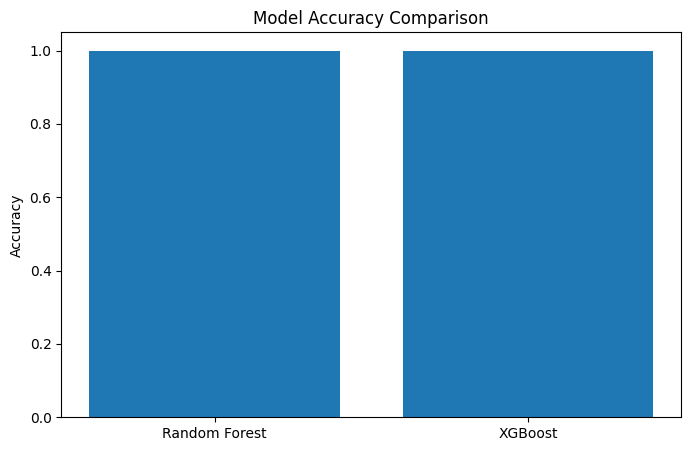

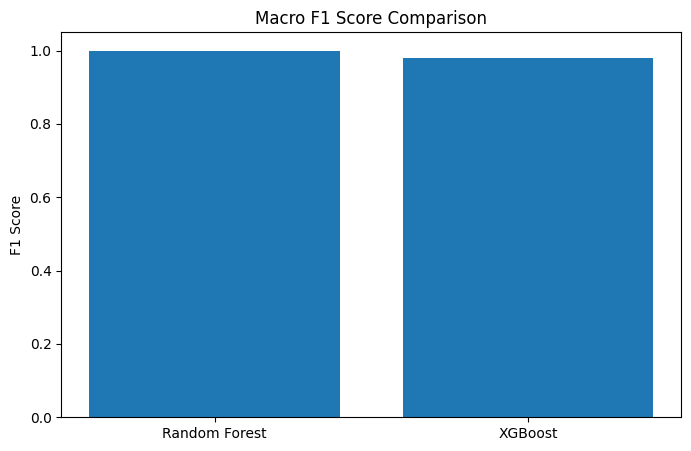

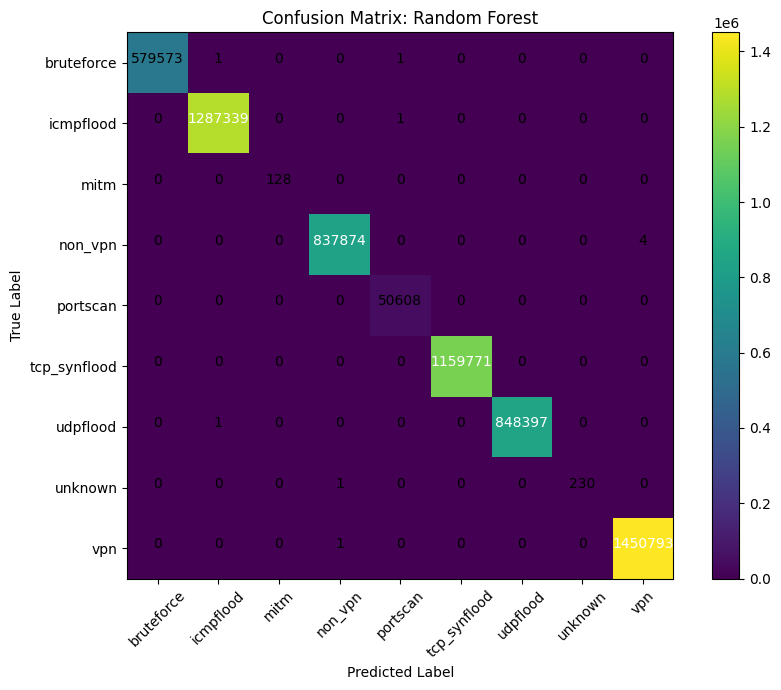

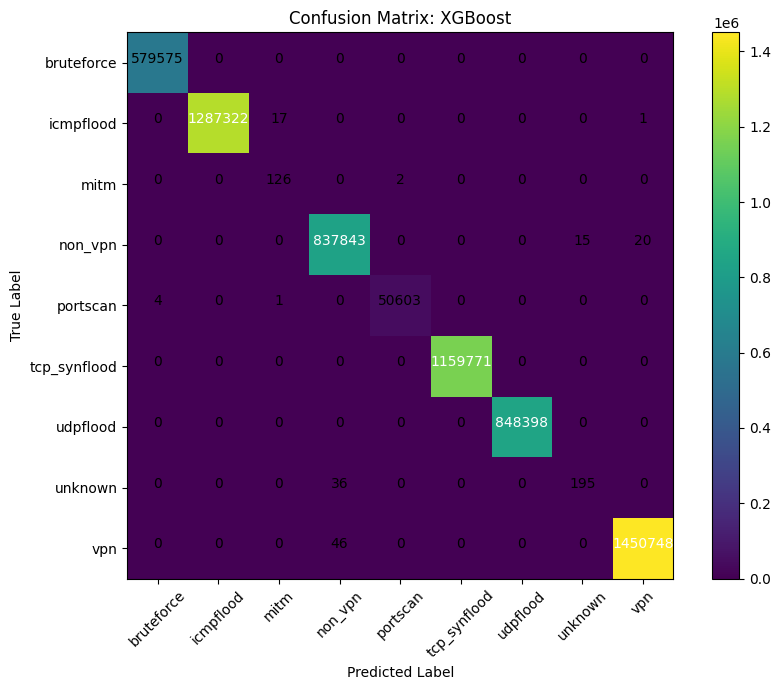

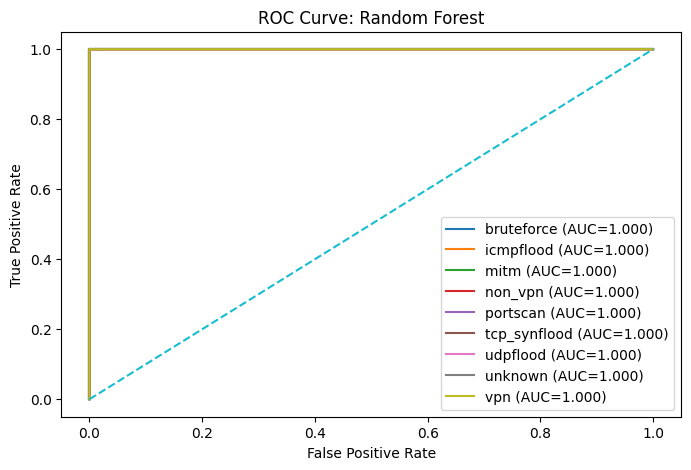

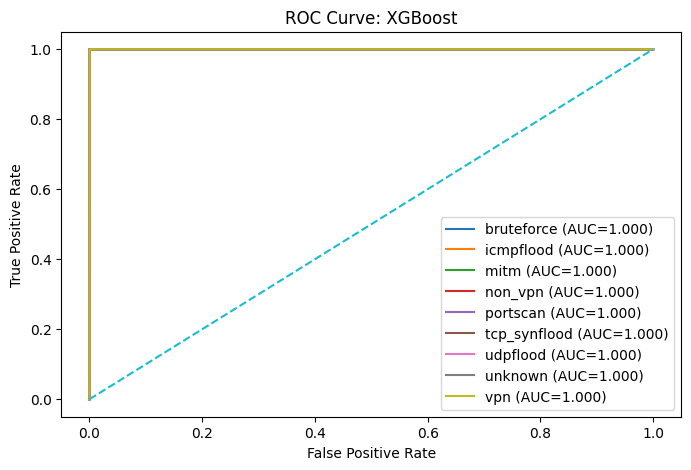

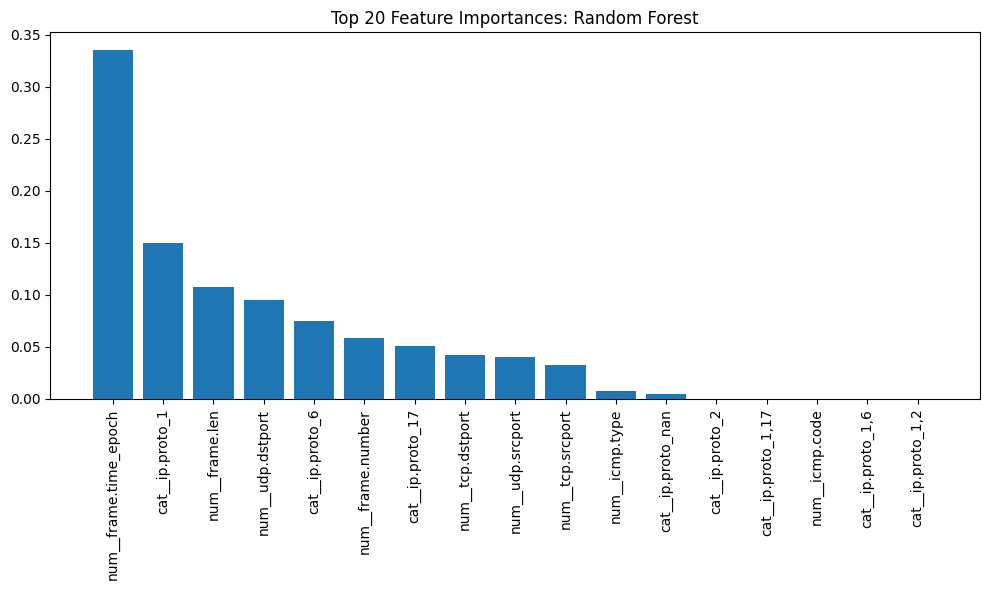

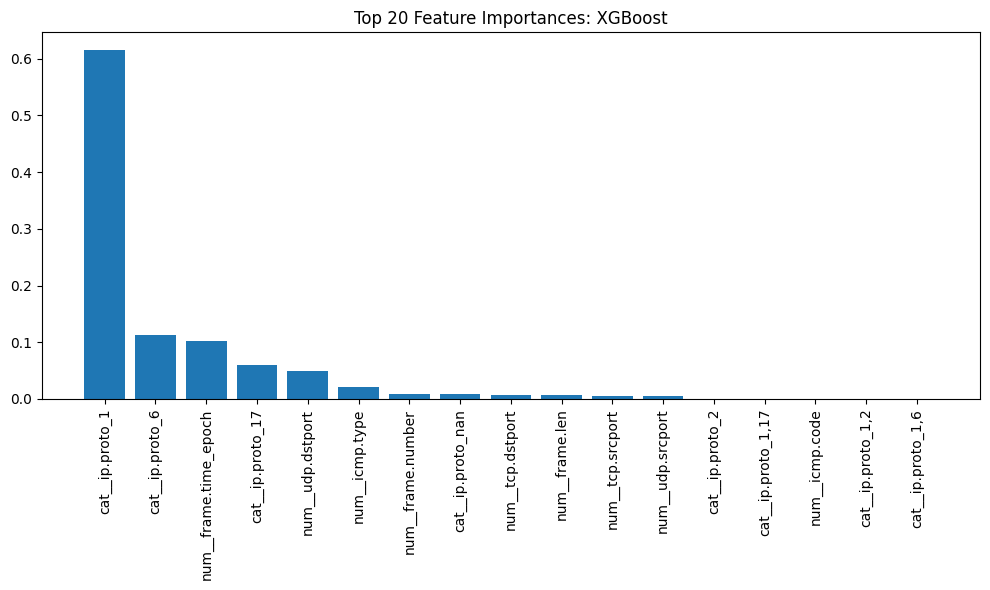

In [49]:
# ================================================
# MODEL COMPARISON TABLE + VISUALIZATIONS
# ================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)
import time
import itertools

models = {
    "Random Forest": rf,
    "XGBoost": xgb_model,
}

# If you trained LightGBM, add:
try:
    models["LightGBM"] = lgb_model
except:
    pass

# ------------------------------------------------
# Helper: compute metrics for each model
# ------------------------------------------------
def evaluate_model(name, model):
    t0 = time.time()
    preds = model.predict(X_test)
    t_pred = time.time() - t0

    acc = accuracy_score(y_test, preds)
    prec_macro = precision_score(y_test, preds, average='macro')
    rec_macro = recall_score(y_test, preds, average='macro')
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_weighted = f1_score(y_test, preds, average='weighted')

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision (Macro)": prec_macro,
        "Recall (Macro)": rec_macro,
        "F1 (Macro)": f1_macro,
        "F1 (Weighted)": f1_weighted,
        "Prediction Time (s)": t_pred
    }

# ------------------------------------------------
# Create comparison table
# ------------------------------------------------
results = []
for name, model in models.items():
    res = evaluate_model(name, model)
    results.append(res)

df_results = pd.DataFrame(results)
display(df_results)

# ================================================
# VISUALISATION 1: Accuracy Bar Chart
# ================================================
plt.figure(figsize=(8,5))
plt.bar(df_results["Model"], df_results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# ================================================
# VISUALISATION 2: Macro-F1 Score
# ================================================
plt.figure(figsize=(8,5))
plt.bar(df_results["Model"], df_results["F1 (Macro)"])
plt.title("Macro F1 Score Comparison")
plt.ylabel("F1 Score")
plt.show()

# ================================================
# VISUALISATION 3: Confusion Matrix Heatmaps
# ================================================
classes = le.classes_

def plot_conf_matrix(cm, model_name):
    plt.figure(figsize=(9,7))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = "d"
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i,j] > thresh else "black")

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

for name, model in models.items():
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    plot_conf_matrix(cm, name)

# ================================================
# VISUALISATION 4: ROC Curves
# ================================================
for name, model in models.items():
    try:
        y_proba = model.predict_proba(X_test)
    except:
        continue

    plt.figure(figsize=(8,5))
    for i, label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test == i, y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")

    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"ROC Curve: {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# ================================================
# VISUALISATION 5: Feature Importance (RF vs XGB)
# ================================================
feature_names = list(preprocessor.get_feature_names_out())

for name, model in models.items():
    try:
        importances = model.feature_importances_
    except:
        continue

    indices = np.argsort(importances)[::-1][:20]  # top 20 features

    plt.figure(figsize=(10,6))
    plt.bar(range(len(indices)), importances[indices])
    plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=90)
    plt.title(f"Top 20 Feature Importances: {name}")
    plt.tight_layout()
    plt.show()


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


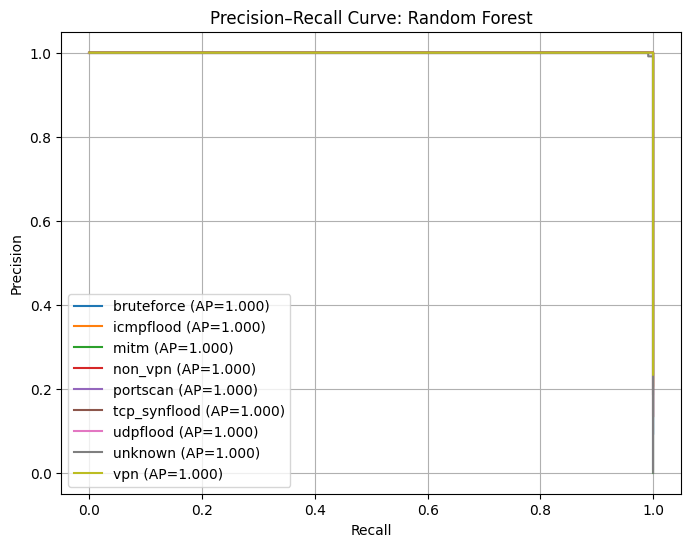

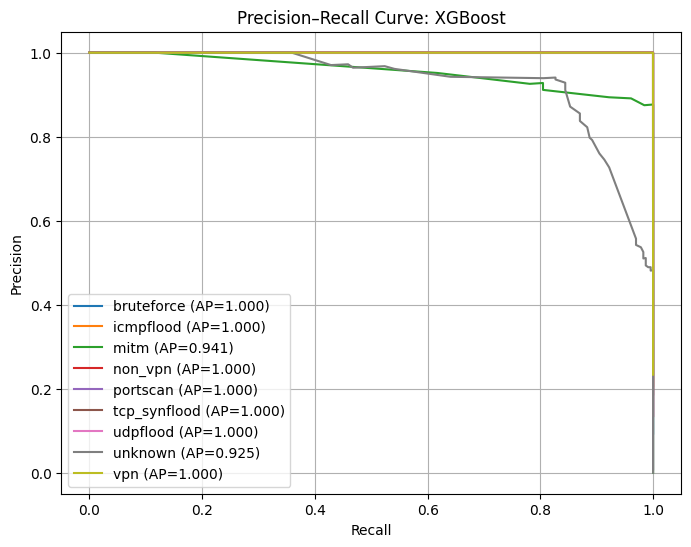

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  or 'coo'. If the method is 'barnes_hut' and the metric is


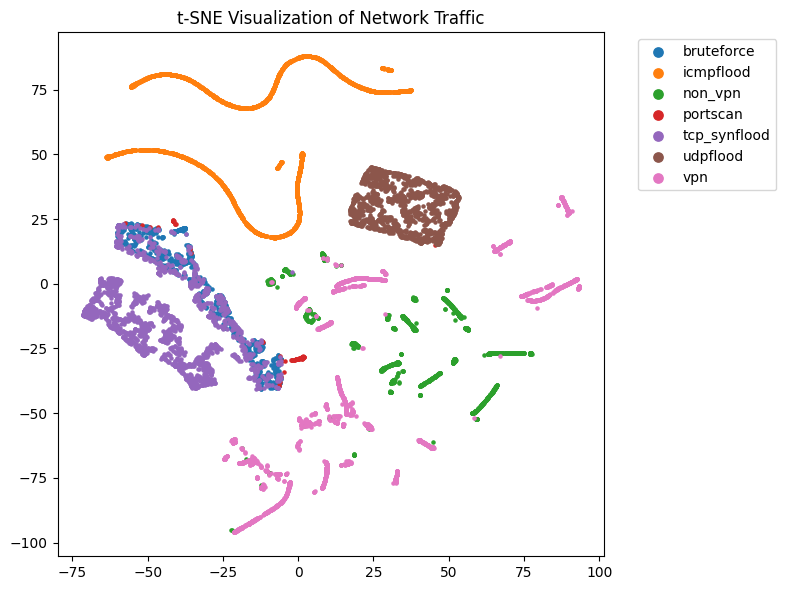

TypeError: check_array() got an unexpected keyword argument 'ensure_all_finite'

In [54]:
# ===============================================================
# FIX 1 — Install Latest UMAP (must be first)
# ===============================================================
!pip install --upgrade umap-learn

# Restart Runtime manually if required:
# In Colab: Runtime → Restart Runtime
# In Jupyter: Kernel → Restart


# ===============================================================
# IMPORTS
# ===============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import label_binarize
import umap  # latest version after upgrade


# ===============================================================
# DEFINE MODELS
# ===============================================================
models = {
    "Random Forest": rf,
    "XGBoost": xgb_model,
}

try:
    models["LightGBM"] = lgb_model
except:
    pass

classes = le.classes_
n_classes = len(classes)


# ===============================================================
# 1. PRECISION–RECALL CURVES (per attack class)
# ===============================================================
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

for name, model in models.items():
    try:
        y_probs = model.predict_proba(X_test)
    except:
        continue

    plt.figure(figsize=(8,6))
    for i, label in enumerate(classes):
        precision, recall, _ = precision_recall_curve(
            y_test_bin[:, i], y_probs[:, i]
        )
        ap = average_precision_score(y_test_bin[:, i], y_probs[:, i])
        plt.plot(recall, precision, label=f"{label} (AP={ap:.3f})")

    plt.title(f"Precision–Recall Curve: {name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()


# ===============================================================
# 2. t-SNE & UMAP VISUALIZATION (sample 10k)
# ===============================================================
sample_size = 10000
idx = np.random.choice(len(X_test), sample_size, replace=False)

X_vis = X_test[idx]
y_vis = y_test[idx]
labels_vis = le.inverse_transform(y_vis)


# ---------------------------- #
# t-SNE (works everywhere)
# ---------------------------- #
tsne = TSNE(
    n_components=2, 
    perplexity=50, 
    learning_rate=300, 
    n_iter=1000
)
X_tsne = tsne.fit_transform(X_vis)

plt.figure(figsize=(8,6))
for cls in np.unique(labels_vis):
    sel = labels_vis == cls
    plt.scatter(X_tsne[sel, 0], X_tsne[sel, 1], s=5, label=cls)

plt.title("t-SNE Visualization of Network Traffic")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# ---------------------------- #
# UMAP (fixed — works with latest version)
# ---------------------------- #
u = umap.UMAP(
    n_components=2, 
    n_neighbors=30, 
    min_dist=0.1,
    metric='euclidean'
)

# ensure float32
X_vis_float = np.asarray(X_vis, dtype=np.float32)

X_umap = u.fit_transform(X_vis_float)

plt.figure(figsize=(8,6))
for cls in np.unique(labels_vis):
    sel = labels_vis == cls
    plt.scatter(X_umap[sel, 0], X_umap[sel, 1], s=5, label=cls)

plt.title("UMAP Visualization of Network Traffic")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# ===============================================================
# 3. MODEL RANKING TABLE (Displayed in notebook)
# ===============================================================
df_rank = df_results.copy()
df_rank = df_rank.sort_values(by="Accuracy", ascending=False)
df_rank.reset_index(drop=True, inplace=True)

print("\n=== MODEL RANKING TABLE (Best → Worst) ===")
display(df_rank)



Table 1: Overview of Dataset Classes


,Class,Count
0,vpn,4835981
1,icmpflood,4291132
2,tcp_synflood,3865903
3,udpflood,2827994
4,non_vpn,2792926
5,bruteforce,1931916
6,portscan,168693
7,unknown,770
8,mitm,427



Table 2: Model Performance Comparison


,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),F1 Score (Weighted)
0,Random Forest,0.999998,0.999995,0.999518,0.999756,0.999998
1,XGBoost,0.999977,0.978157,0.980927,0.978961,0.999977



Table 3: Adversarial Attack Flip Rates Summary


,Attack Strategy,Flipped Samples,Flip Rate (%)
0,Random Perturbation,108,21.6
1,Greedy Hill-Climb,371,74.2
2,Blackbox Iterative,231,46.2


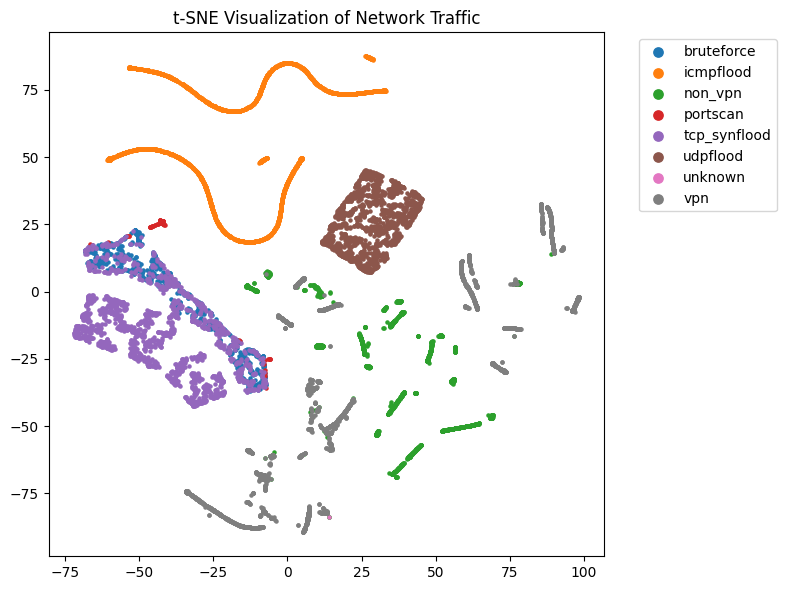

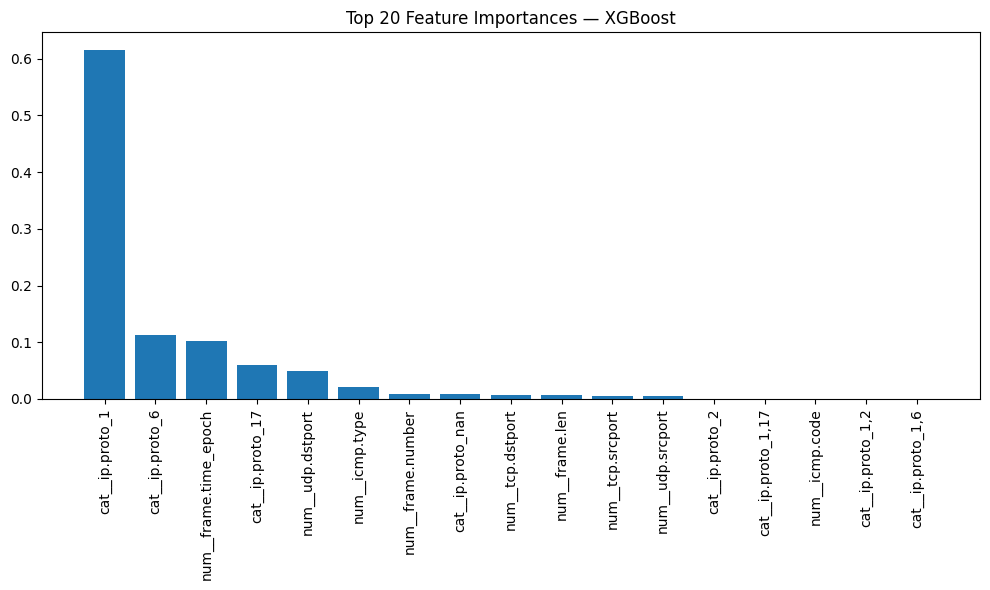

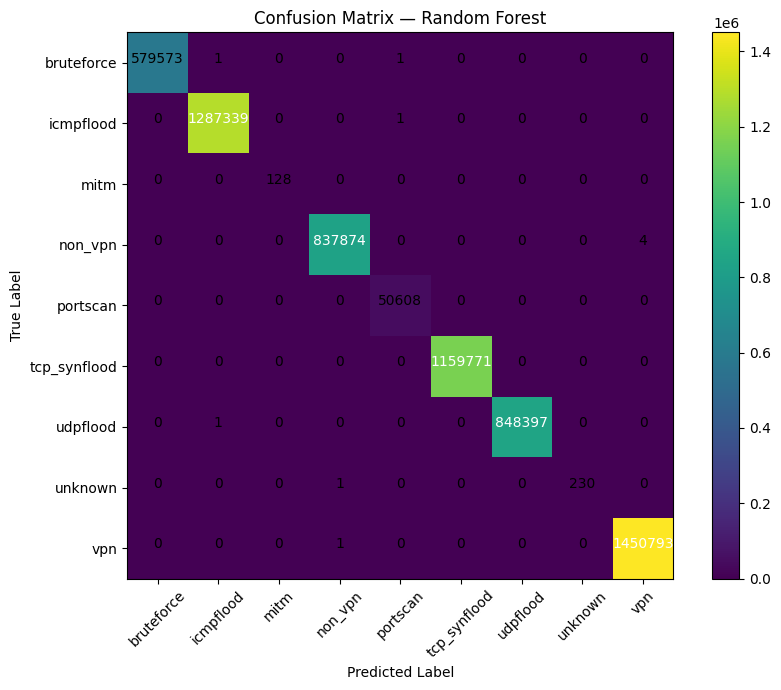

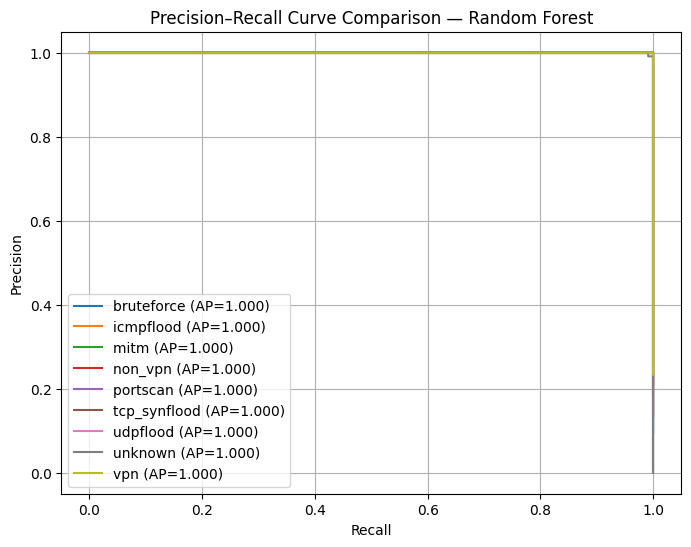

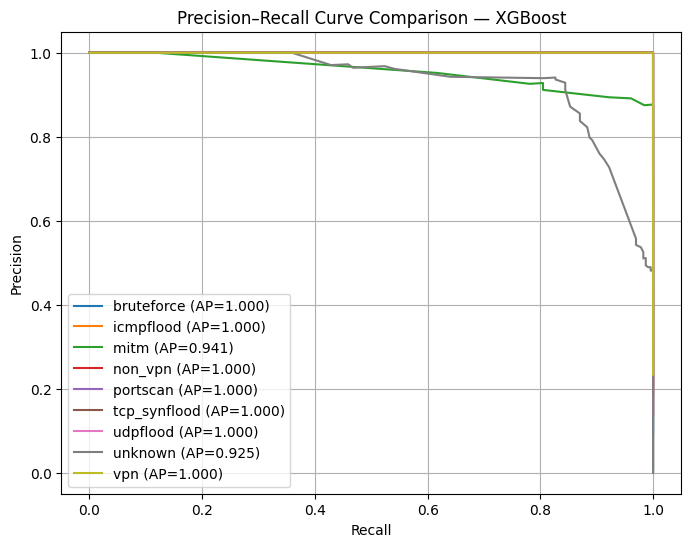

In [52]:
# ========================================
# TABLE 1 — Overview of Dataset Classes
# ========================================
import pandas as pd

table1 = df['label'].value_counts().reset_index()
table1.columns = ['Class', 'Count']

print("\nTable 1: Overview of Dataset Classes")
display(table1)
# ========================================
# TABLE 2 — Model Performance Comparison
# ========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Random Forest": rf,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision (Macro)": precision_score(y_test, preds, average="macro"),
        "Recall (Macro)": recall_score(y_test, preds, average="macro"),
        "F1 Score (Macro)": f1_score(y_test, preds, average="macro"),
        "F1 Score (Weighted)": f1_score(y_test, preds, average="weighted")
    })

table2 = pd.DataFrame(results)

print("\nTable 2: Model Performance Comparison")
display(table2)
# ========================================
# TABLE 3 — Adversarial Attack Flip Rates
# ========================================
import pandas as pd
import numpy as np

total = len(baseline_flips)

table3 = pd.DataFrame({
    "Attack Strategy": ["Random Perturbation", "Greedy Hill-Climb", "Blackbox Iterative"],
    "Flipped Samples": [
        np.sum(baseline_flips),
        np.sum(gc_flips),
        np.sum(bb_flips)
    ],
    "Flip Rate (%)": [
        100 * np.sum(baseline_flips) / total,
        100 * np.sum(gc_flips) / total,
        100 * np.sum(bb_flips) / total
    ]
})

print("\nTable 3: Adversarial Attack Flip Rates Summary")
display(table3)
# ========================================
# FIGURE 2 — t-SNE Clustering
# ========================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# sample 10k rows for clarity
sample_size = 10000
idx = np.random.choice(len(X_test), sample_size, replace=False)

X_vis = X_test[idx]
y_vis = y_test[idx]
labels_vis = le.inverse_transform(y_vis)

tsne = TSNE(n_components=2, perplexity=50, learning_rate=300)
X_tsne = tsne.fit_transform(X_vis)

plt.figure(figsize=(8,6))

for cls in np.unique(labels_vis):
    sel = labels_vis == cls
    plt.scatter(X_tsne[sel, 0], X_tsne[sel, 1], s=5, label=cls)

plt.title("t-SNE Visualization of Network Traffic")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# ========================================
# FIGURE 3 — XGBoost Feature Importance
# ========================================
import matplotlib.pyplot as plt
import numpy as np

feature_names = list(preprocessor.get_feature_names_out())
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # top 20

plt.figure(figsize=(10,6))
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=90)
plt.title("Top 20 Feature Importances — XGBoost")
plt.tight_layout()
plt.show()
# ========================================
# FIGURE 4 — Random Forest Confusion Matrix
# ========================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, pred_rf)
classes = le.classes_

plt.figure(figsize=(9,7))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix — Random Forest")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i,j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()
# ========================================
# FIGURE 5 — Precision–Recall Curves
# ========================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

for name, model in models.items():
    try:
        y_proba = model.predict_proba(X_test)
    except:
        continue

    plt.figure(figsize=(8,6))
    for i, label in enumerate(classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
        ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
        plt.plot(recall, precision, label=f"{label} (AP={ap:.3f})")

    plt.title(f"Precision–Recall Curve Comparison — {name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()


In [57]:
# Setup: imports and safety sampling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os
synthetic_df = pd.read_csv("synthetic_predictions.csv")


# Optional: UMAP (install if not present: pip install umap-learn)
try:
    from umap import UMAP
    umap_available = True
except Exception:
    umap_available = False

# Adjust these names to match your variables
# df = original real raw DataFrame (columns include 'frame.len', 'ip.proto', ...)
# synthetic_df = CTGAN/other synthetic DataFrame with same columns (or compatible)

# SAMPLE sizes (reduce for speed / memory)
REAL_SAMPLE = 50000   # number of real rows to sample for visualizations (reduce if memory limited)
SYNTH_SAMPLE = 20000  # number of synthetic rows to sample

# ensure variables exist
assert 'df' in globals(), "Please load your real DataFrame into variable named `df`"
assert 'synthetic_df' in globals(), "Please load your synthetic DataFrame into `synthetic_df`"

# sample safely (without replacement)
real_sample = df.sample(n=min(REAL_SAMPLE, len(df)), random_state=42).reset_index(drop=True)
synth_sample = synthetic_df.sample(n=min(SYNTH_SAMPLE, len(synthetic_df)), random_state=42).reset_index(drop=True)

print("Real sample:", real_sample.shape, "Synthetic sample:", synth_sample.shape)


Real sample: (50000, 11) Synthetic sample: (7000, 12)


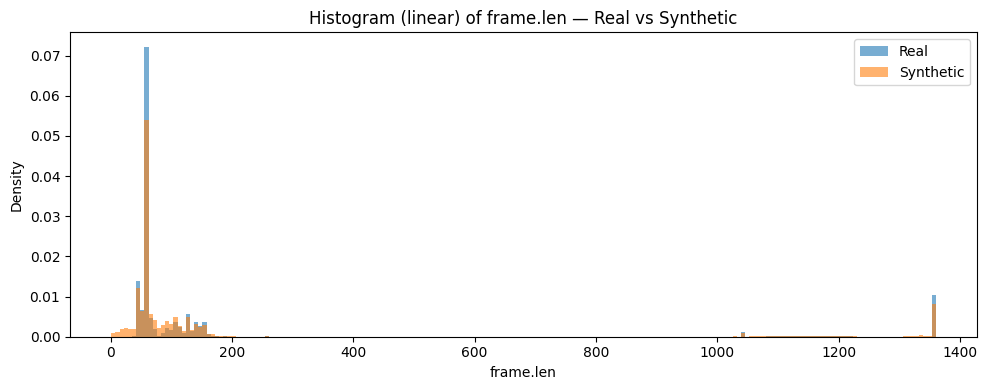

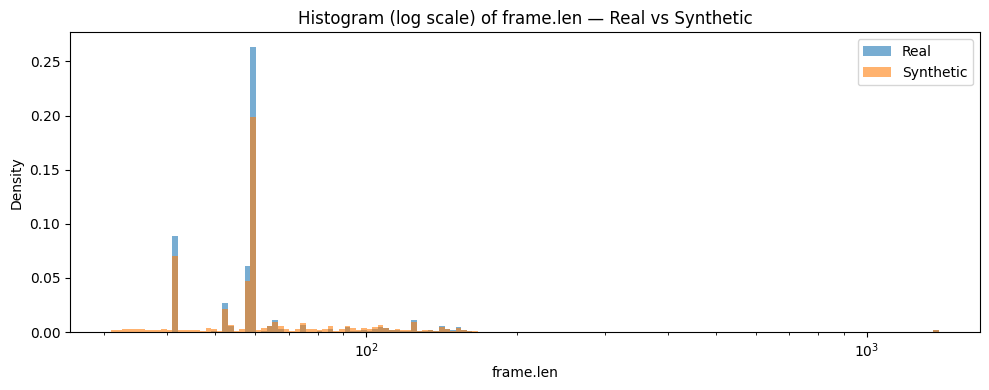

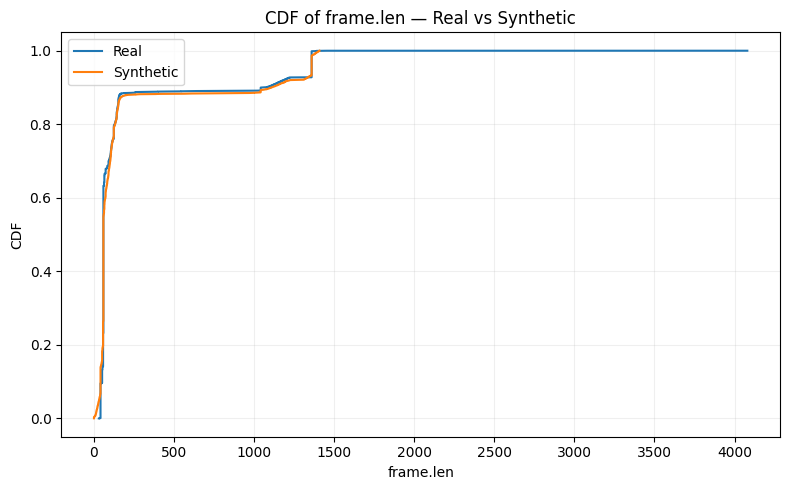

In [59]:
# Histogram + CDF for frame.len (real vs synthetic)
import matplotlib.pyplot as plt
import numpy as np

col = 'frame.len'

# make sure numeric
real_vals = pd.to_numeric(real_sample[col], errors='coerce').dropna().values
synth_vals = pd.to_numeric(synth_sample[col], errors='coerce').dropna().values

# Linear histogram
plt.figure(figsize=(10,4))
bins = np.linspace(min(min(real_vals), min(synth_vals)), np.percentile(np.concatenate([real_vals, synth_vals]), 99.5), 200)
plt.hist(real_vals, bins=bins, alpha=0.6, label='Real', density=True)
plt.hist(synth_vals, bins=bins, alpha=0.6, label='Synthetic', density=True)
plt.title(f'Histogram (linear) of {col} — Real vs Synthetic')
plt.xlabel(col); plt.ylabel('Density'); plt.legend()
plt.tight_layout()
plt.savefig('hist_frame_len_linear.png', dpi=200)
plt.show()

# Log-scale histogram (helps heavy tails)
plt.figure(figsize=(10,4))
# avoid zeros
real_vals_pos = real_vals[real_vals > 0]
synth_vals_pos = synth_vals[synth_vals > 0]
bins = np.logspace(np.log10(max(1, real_vals_pos.min(), synth_vals_pos.min())), np.log10(np.percentile(np.concatenate([real_vals_pos, synth_vals_pos]), 99.9)), 150)
plt.hist(real_vals_pos, bins=bins, alpha=0.6, label='Real', density=True)
plt.hist(synth_vals_pos, bins=bins, alpha=0.6, label='Synthetic', density=True)
plt.xscale('log')
plt.title(f'Histogram (log scale) of {col} — Real vs Synthetic')
plt.xlabel(col); plt.ylabel('Density'); plt.legend()
plt.tight_layout()
plt.savefig('hist_frame_len_log.png', dpi=200)
plt.show()

# CDF plot
def cdf_plot(a, label):
    a_sorted = np.sort(a)
    p = np.arange(1, len(a_sorted)+1) / len(a_sorted)
    plt.plot(a_sorted, p, label=label)

plt.figure(figsize=(8,5))
cdf_plot(real_vals, 'Real')
cdf_plot(synth_vals, 'Synthetic')
plt.xlabel(col); plt.ylabel('CDF'); plt.title(f'CDF of {col} — Real vs Synthetic')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('cdf_frame_len.png', dpi=200)
plt.show()


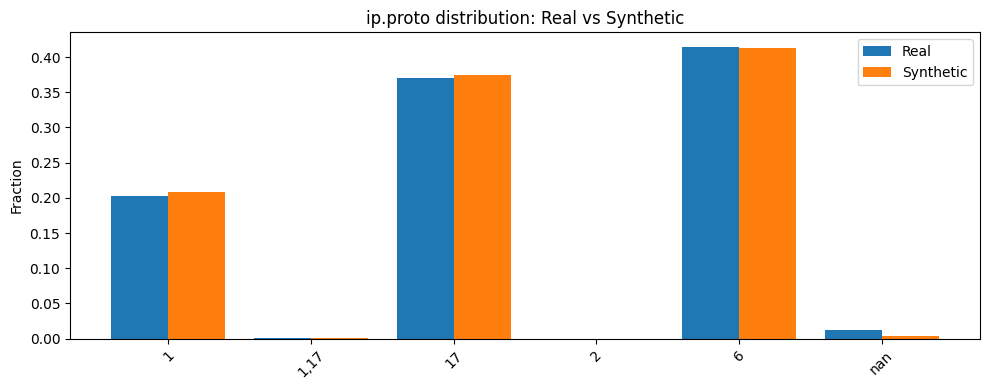

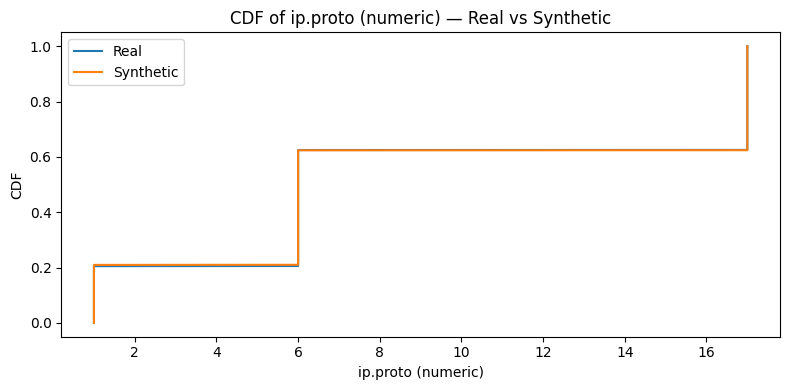

In [60]:
# ip.proto distribution comparison (categorical)
col = 'ip.proto'

# convert to string for grouping
real_proto = real_sample[col].astype(str).fillna('nan')
synth_proto = synth_sample[col].astype(str).fillna('nan')

real_counts = real_proto.value_counts(normalize=True).sort_index()
synth_counts = synth_proto.value_counts(normalize=True).sort_index()

# union of categories
cats = sorted(set(real_counts.index) | set(synth_counts.index), key=lambda x: str(x))

real_freq = [real_counts.get(c, 0.0) for c in cats]
synth_freq = [synth_counts.get(c, 0.0) for c in cats]

x = np.arange(len(cats))
width = 0.4

plt.figure(figsize=(10,4))
plt.bar(x - width/2, real_freq, width=width, label='Real')
plt.bar(x + width/2, synth_freq, width=width, label='Synthetic')
plt.xticks(x, cats, rotation=45)
plt.ylabel('Fraction')
plt.title('ip.proto distribution: Real vs Synthetic')
plt.legend()
plt.tight_layout()
plt.savefig('ip_proto_distribution.png', dpi=200)
plt.show()

# Also plot CDF of protocol as cumulative frequency (if numeric)
try:
    real_proto_num = pd.to_numeric(real_sample[col], errors='coerce').dropna().values
    synth_proto_num = pd.to_numeric(synth_sample[col], errors='coerce').dropna().values
    plt.figure(figsize=(8,4))
    cdf_plot(real_proto_num, 'Real')
    cdf_plot(synth_proto_num, 'Synthetic')
    plt.xlabel('ip.proto (numeric)')
    plt.ylabel('CDF')
    plt.title('CDF of ip.proto (numeric) — Real vs Synthetic')
    plt.legend()
    plt.tight_layout()
    plt.savefig('cdf_ip_proto.png', dpi=200)
    plt.show()
except Exception:
    pass


PCA output shape: (27000, 10)


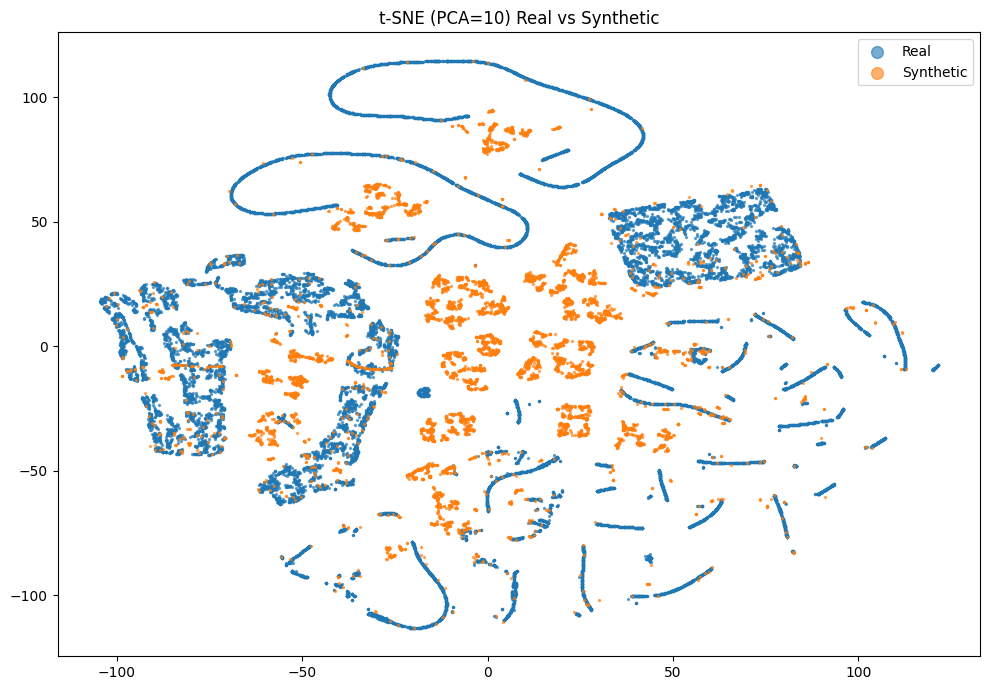

In [62]:
# PCA → t-SNE (fixed for 17-feature dataset)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# PCA to 10 dims (compatible with 17 features)
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_comb)

print("PCA output shape:", X_pca.shape)

# t-SNE to 2D
tsne = TSNE(
    n_components=2,
    perplexity=50,      # OK for ~20k real + 7k synth
    random_state=42,
    n_jobs=-1
)
X_tsne = tsne.fit_transform(X_pca)

# Plot Real vs Synthetic
plt.figure(figsize=(10,7))
mask_real = labels == 'real'
mask_synth = labels == 'synth'

plt.scatter(X_tsne[mask_real,0], X_tsne[mask_real,1], s=2, alpha=0.6, label="Real")
plt.scatter(X_tsne[mask_synth,0], X_tsne[mask_synth,1], s=2, alpha=0.6, label="Synthetic")

plt.legend(markerscale=6)
plt.title("t-SNE (PCA=10) Real vs Synthetic")
plt.tight_layout()
plt.savefig('tsne_real_vs_synth_fixed.png', dpi=200)
plt.show()


In [65]:
!pip install openTSNE


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 3.4 MB/s  0:00:00 eta 0:00:01m


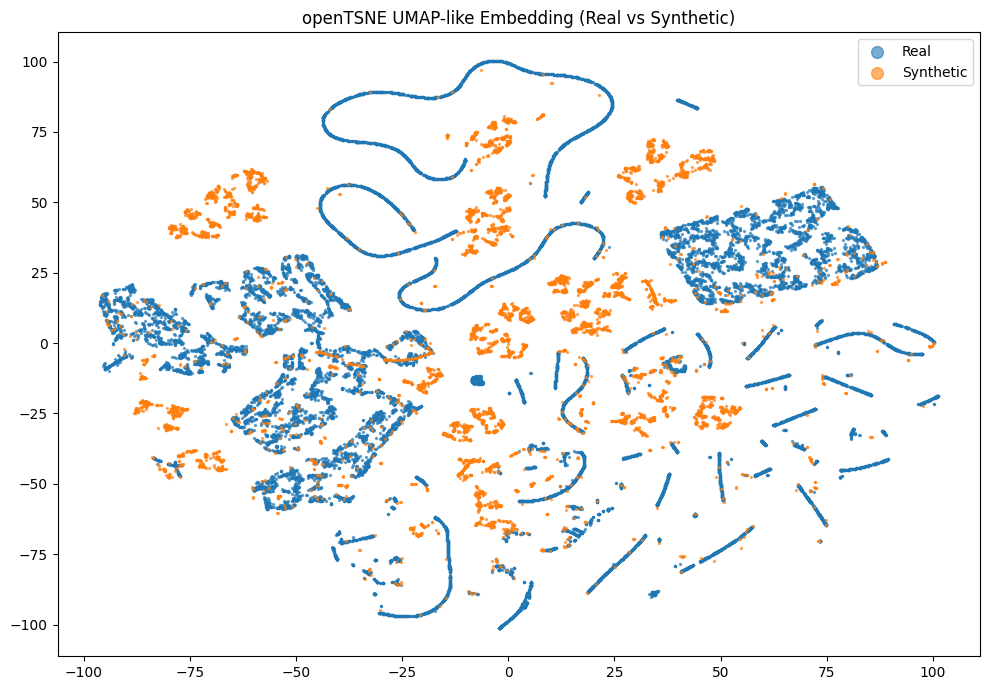

In [66]:
from openTSNE import TSNE
import numpy as np
import matplotlib.pyplot as plt

# convert to float32 (important)
X = X_comb.astype(np.float32)

# openTSNE with UMAP initialization (works even when UMAP fails)
tsne = TSNE(
    n_components=2,
    initialization="pca",  # stable initial layout
    metric="euclidean",
    n_jobs=8,
    random_state=42,
    perplexity=50
)

X_tsne_umap_like = tsne.fit(X)

# Plot
plt.figure(figsize=(10,7))
mask_real = labels == "real"
mask_synth = labels == "synth"

plt.scatter(X_tsne_umap_like[mask_real,0], X_tsne_umap_like[mask_real,1], s=2, alpha=0.6, label="Real")
plt.scatter(X_tsne_umap_like[mask_synth,0], X_tsne_umap_like[mask_synth,1], s=2, alpha=0.6, label="Synthetic")

plt.legend(markerscale=6)
plt.title("openTSNE UMAP-like Embedding (Real vs Synthetic)")
plt.tight_layout()
plt.savefig("openTSNE_real_vs_synth.png", dpi=200)
plt.show()
